GROUP NUMBER: 3

GROUP MEMBER: A.HEMANT KUMAAR, JACK LICHWA , PRITHIKA K

# **PIT STOP ANALYSIS PROJECT**

## **PROJECT BACKGROUND**

Formula 1 (F1) is the pinnacle of motorsport, combining elite driver skill with cutting-edge engineering. A critical and often race-deciding element of F1 strategy is the **pit stop**  a brief pause in which a team changes tires, makes aerodynamic adjustments, or responds to race incidents. The duration of a pit stop, even down to fractions of a second, can determine whether a driver retains or loses a podium position.

For top-finishing drivers (those who finish in the top 3), pit stop strategy is especially high-stakes. A slow stop can cost a driver a podium; an efficiently timed stop can vault them ahead of a competitor. Understanding what factors influence the **maximum pit stop duration** experienced by top 3 finishers has implications for race engineering, team strategy optimization, and performance analytics.

This study investigates whether historical race data, tire information, and race conditions can be used to predict the maximum pit stop duration among the top three drivers in a Formula 1 race. Can the maximum pit stop duration for the top 3 drivers in a Formula 1 race be predicted using race context and historical performance data?

## **DATASET**

**Source**: All datasets come from Kaggle: “Formula 1 Race Data” by jtrotman. https://www.kaggle.com/datasets/jtrotman/formula-1-race-data?resource=download&select=lap_times.csv

They contain historical Formula 1 data from 1950 onwards, including race results, circuits, drivers, constructors, lap times, pit stops, qualifying, sprint results, and season standings.

**Key Variable**:
At this stage, we are exploring all variables from the pit stops, races, circuits, drivers, constructors, lap times, qualifying, and results datasets. Final selection of key predictor variables will be based on further analysis and exploratory data analysis (EDA), including correlations, distributions, and relevance to pit stop duration.

**Data Type**: The datasets include a mix of numeric, categorical, ordinal, and datetime variables:

- Numeric: milliseconds, lap, round, year, alt, points, positionOrder
- Categorical: driverId, surname, constructorId, constructor name, circuitId, location, country, status
- Ordinal: stop (pit stop sequence), grid position, and finishing positions
- Datetime: race dates (races.date) and driver birth dates (drivers.dob)

These variables provide the foundation for preprocessing and exploratory analysis to identify potential predictors for pit stop duration.



| File | Description |
|---|---|
| `pit_stops.csv` | Per-stop timing data for every driver in every race (1994+) |
| `results.csv` | Final race outcomes: grid, finish position, points, laps, fastest lap |
| `races.csv` | Race metadata: year, round, circuit, date |
| `circuits.csv` | Circuit details: name, location, country, altitude |
| `drivers.csv` | Driver info: name, nationality, date of birth |
| `constructors.csv` | Constructor (team) name and nationality |
| `lap_times.csv` | Per-lap timing for every driver (used to derive race pace features) |
| `qualifying.csv` | Q1/Q2/Q3 qualifying times per driver per race |
| `driver_standings.csv` | Cumulative championship standings after each race |
| `constructor_standings.csv` | Cumulative constructor championship standings |
| `status.csv` | Lookup: race exit status (Finished, Engine, Accident, etc.) |


### **SETUP AND DATA LOADING**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report, mean_squared_error, mean_absolute_error, r2_score, silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from xgboost import XGBRegressor, XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (11, 5)

print('Libraries loaded.')


In [ ]:
import kagglehub

# Download latest version using kagglehub
path = kagglehub.dataset_download("jtrotman/formula-1-race-data")

DATA_PATH = path + '/' # Set DATA_PATH to the downloaded directory

pit_stops            = pd.read_csv(DATA_PATH + 'pit_stops.csv')
results              = pd.read_csv(DATA_PATH + 'results.csv')
races                = pd.read_csv(DATA_PATH + 'races.csv')
circuits             = pd.read_csv(DATA_PATH + 'circuits.csv')
drivers              = pd.read_csv(DATA_PATH + 'drivers.csv')
constructors         = pd.read_csv(DATA_PATH + 'constructors.csv')
lap_times            = pd.read_csv(DATA_PATH + 'lap_times.csv')
qualifying           = pd.read_csv(DATA_PATH + 'qualifying.csv')
driver_standings     = pd.read_csv(DATA_PATH + 'driver_standings.csv')
constructor_standings= pd.read_csv(DATA_PATH + 'constructor_standings.csv')
status               = pd.read_csv(DATA_PATH + 'status.csv')

print('All files loaded.')

all_dfs = {
    'pit_stops': pit_stops, 'results': results, 'races': races,
    'circuits': circuits, 'drivers': drivers, 'constructors': constructors,
    'lap_times': lap_times, 'qualifying': qualifying,
    'driver_standings': driver_standings, 'status': status
}
print(f"\n{'File':<28} {'Rows':>10} {'Cols':>6}")
print('-' * 46)
for name, df in all_dfs.items():
    print(f'{name:<28} {df.shape[0]:>10,} {df.shape[1]:>6}')

**Key Variable Definitions & Data Types**

The dataset contains a mix of numeric, categorical, ordinal, and datetime variables across files.

`pit_stops.csv` — Primary File
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `raceId` | Integer — **Nominal** | Join key | Links to `races.csv` |
| `driverId` | Integer — **Nominal** | Join key | Links to `drivers.csv` |
| `stop` | Integer — **Ordinal** | Predictor | Pit stop sequence number (1st, 2nd, 3rd…) |
| `lap` | Integer — **Discrete** | Predictor | Lap on which the pit stop occurred |
| `time` | String (HH:MM:SS) | Context | Clock time of pit stop |
| `duration` | Float — **Continuous** | Feature / Target-component | Pit stop duration in seconds |
| `milliseconds` | Integer — **Continuous** | Feature / Target-component | Duration in milliseconds |

 `results.csv` — Race Outcomes
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `grid` | Integer — **Ordinal** | Predictor | Starting grid position |
| `positionOrder` | Integer — **Ordinal** | Filter / Predictor | Final finishing position |
| `points` | Float — **Continuous** | Predictor | Championship points earned |
| `laps` | Integer — **Discrete** | Predictor | Total laps completed |
| `fastestLapSpeed` | Float — **Continuous** | Predictor | Speed (km/h) of driver's fastest lap |
| `statusId` | Integer — **Nominal** | Filter | Links to `status.csv` |
| `constructorId` | Integer — **Nominal** | Join key | Links to `constructors.csv` |

`races.csv`
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `year` | Integer — **Ordinal** | Predictor | Season year |
| `round` | Integer — **Ordinal** | Predictor | Race round within the season |
| `circuitId` | Integer — **Nominal** | Join key | Links to `circuits.csv` |
| `date` | String → **Datetime** | Feature | Date of the race |

`circuits.csv`
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `name` | String — **Categorical** | Predictor | Circuit name |
| `country` | String — **Categorical** | Predictor | Host country |
| `location` | String — **Categorical** | Context | City/region |
| `alt` | Integer — **Continuous** | Predictor | Circuit altitude (meters) — affects engine/tire behavior |
| `lat` / `lng` | Float — **Continuous** | Context | Geographic coordinates |

`drivers.csv`
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `surname` | String — **Categorical** | Context | Driver last name |
| `nationality` | String — **Categorical** | Predictor | Driver nationality |
| `dob` | String → **Datetime** | Feature-eng | Date of birth (used to compute driver age at race) |

`qualifying.csv`
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `position` | Integer — **Ordinal** | Predictor | Final qualifying position |
| `q1`, `q2`, `q3` | String → Float — **Continuous** | Predictor | Qualifying lap times per session |


### DATA PROFILING AND CLEANING

This section prepares the dataset for analysis by checking data quality and applying the basic cleaning needed for the project.

In [ ]:
# --- Inspecting data ---
print('=== DATA Analysis ===')

print('\npit_stops info:\n')
pit_stops.info()

print('\n\nresults info (selected columns):\n')
results_subset = results[['grid', 'positionOrder', 'points', 'laps']]
results_subset.info()

print('\n\nraces info (selected columns):\n')
races_subset = races[['date', 'year']]
races_subset.info()

print('\n\ncircuits info (selected columns):\n')
circuits_subset = circuits[['circuitId', 'name', 'country', 'alt', 'lng', 'lat', 'url']]
circuits_subset.info()

print('\n\ndrivers info (selected columns):\n')
drivers_subset = drivers[['driverId', 'surname', 'dob']]
drivers_subset.info()

print("\n\nqualyfing inf (selected columns):\n")
qualifying_subset = qualifying[
    ['raceId', 'driverId', 'constructorId', 'position', 'q1', 'q2', 'q3']
]
qualifying_subset.info()


In [ ]:
# === Core type conversions and cleaning ===

# duration, milliseconds numeric; keep time as string for now (HH:MM:SS)
pit_stops['duration'] = pd.to_numeric(pit_stops['duration'], errors='coerce')
pit_stops['milliseconds'] = pd.to_numeric(pit_stops['milliseconds'], errors='coerce')

# Drop pit_stop rows without usable duration
pit_stops = pit_stops.dropna(subset=['duration']).copy()

# results
results['grid'] = pd.to_numeric(results['grid'], errors='coerce').astype('Int64')

# races
races['date'] = pd.to_datetime(races['date'], errors='coerce')

# drivers
drivers['dob'] = pd.to_datetime(drivers['dob'], errors='coerce')

# qualyfing
def lap_to_seconds(x):
    if pd.isna(x) or x == r'\N':
        return np.nan
    x = str(x).strip()
    if ':' in x:
        m, s = x.split(':')
        return int(m) * 60 + float(s)
    return float(x)

for col in ['q1', 'q2', 'q3']:
    if col in qualifying.columns:
        qualifying[col] = qualifying[col].apply(lap_to_seconds)

print("\nConverted dtypes (selected):")
print("pit_stops:", pit_stops[['duration', 'milliseconds']].dtypes.to_dict())
print("results:", {c: results[c].dtype for c in ['grid', 'positionOrder', 'points', 'laps'] if c in results.columns})
print("races:", races[['year', 'round', 'date']].dtypes.to_dict())
print("circuits:", circuits[['alt', 'lat', 'lng']].dtypes.to_dict())
print("drivers:", drivers[['dob']].dtypes.to_dict())
print("qualifying:", {c: qualifying[c].dtype for c in ['position', 'q1', 'q2', 'q3'] if c in qualifying.columns})

### MERGE DATASETS

In [ ]:
# Build one unified source dataset (driver-race grain, expanded with pit stop detail)
race_dim = races[['raceId', 'year', 'round', 'circuitId', 'name', 'date']].rename(columns={'name': 'race_name'})
circuit_dim = circuits[['circuitId', 'name', 'country', 'alt', 'lat', 'lng']].rename(columns={'name': 'circuit_name'})
driver_dim = drivers[['driverId', 'forename', 'surname', 'nationality', 'dob']]
constructor_dim = constructors[['constructorId', 'name']].rename(columns={'name': 'constructor_name'})
qualifying_dim = qualifying[['raceId', 'driverId', 'position', 'q1']]

results_base = results[['raceId', 'driverId', 'constructorId', 'grid', 'laps', 'positionOrder', 'points', 'statusId']].copy()
results_base['laps'] = pd.to_numeric(results_base['laps'], errors='coerce').astype('Int64')
results_base['positionOrder'] = pd.to_numeric(results_base['positionOrder'], errors='coerce').astype('Int64')

# Pit stop aggregates per driver per race
pit_driver = (
    pit_stops.groupby(['raceId', 'driverId'], as_index=False)
    .agg(
        total_pit_stops=('stop', 'count'),
        avg_stop_lap=('lap', 'mean'),
        mean_pit_duration=('duration', 'mean'),
        max_pit_duration=('duration', 'max'),
        min_pit_duration=('duration', 'min')
    )
)

# Pit stop detail per stop (lap-level) — needed for place-specific pivot in feature construction
pit_detail = pit_stops[['raceId', 'driverId', 'stop', 'lap', 'duration', 'milliseconds']].copy()
pit_detail['lap'] = pd.to_numeric(pit_detail['lap'], errors='coerce')
pit_detail['stop'] = pd.to_numeric(pit_detail['stop'], errors='coerce')

driver_race_df = (
    results_base
    .merge(race_dim,        on='raceId',               how='left')
    .merge(circuit_dim,     on='circuitId',             how='left')
    .merge(driver_dim,      on='driverId',              how='left')
    .merge(constructor_dim, on='constructorId',         how='left')
    .merge(qualifying_dim,  on=['raceId', 'driverId'],  how='left')
    .merge(pit_driver,      on=['raceId', 'driverId'],  how='left')
)

driver_race_df['position'] = driver_race_df['position'].astype('Int64')
driver_race_df['total_pit_stops'] = driver_race_df['total_pit_stops'].astype('Int64')

# Expand to pit-stop grain (one row per driver-race-stop)
driver_race_df = driver_race_df.merge(pit_detail, on=["raceId", "driverId"], how="left")

print('Unified dataset complete.')
print(f'driver_race_df shape (driver-race grain): {driver_race_df.shape}')
driver_race_df.info()


Based on above there is missing pit stop data for races. The chart below shows, per season, how many races lack any pit stop records: every season before 1994 is missing entirely (those years are removed next), and the remaining gaps are handled in the EDA section.

In [ ]:
races_missing_pit_by_year = (
    driver_race_df.groupby(['year', 'raceId'])['max_pit_duration']
    .count()
    .eq(0)
    .groupby(level='year')
    .sum()
    .reset_index(name='races_missing_pit')
)
total_races_by_year = driver_race_df.groupby('year')['raceId'].nunique()

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(total_races_by_year.index, total_races_by_year.values,
       color='#9ecae1', label='Total races')
ax.bar(races_missing_pit_by_year['year'], races_missing_pit_by_year['races_missing_pit'],
       color='#d62728', alpha=0.85, label='Races missing pit data')
ax.set_xlabel('Year')
ax.set_ylabel('Races')
ax.set_title('Races with Missing Pit Stop Data by Year', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Remove rows from before 1994
driver_race_df = driver_race_df[driver_race_df['year'] >= 1994].copy()
driver_race_df.to_csv('driver_race_tmp.csv', index=False)


Remaing missing data will be handled in the EDA section.

## EDA

This section will explore, analyze and visualize pit stop dataset. It will enhance dataset with engineered features.

### DATA PREPROCESSING AND FEATURE ENGINEERING

In [ ]:
# Start EDA from Dataset-section handoff (fallback to driver_level_df for compatibility)
df = pd.read_csv('driver_race_tmp.csv')


display(df.head(5))
print('\nShape:')
print(df.shape)
print('\nData types :')
print(df.dtypes)

In [ ]:
print('=== eda_df missing values (top 20 columns with data gaps) ===')
missing_counts = df.isna().sum().sort_values(ascending=False)
display(missing_counts.head(20).to_frame('missing_count'))

display(df.describe(include=[np.number]))

**HANDLING MISSING VALUES**

Dropping races with missing pit stop data, as they cannot contribute to the target variable.

In [ ]:
df_cleaned = df.dropna(subset=['max_pit_duration']).copy()
print(f"Cleaned df shape: {df_cleaned.shape}")

# Drop races where any of the top-3 finishers lack pit stop data
podium_coverage = (
    df_cleaned[df_cleaned['positionOrder'].between(1, 3)]
    .drop_duplicates(subset=['raceId', 'driverId'])
    .groupby('raceId')['positionOrder']
    .nunique()
)
complete_races = podium_coverage[podium_coverage == 3].index
incomplete = len(podium_coverage) - len(complete_races)
df_cleaned = df_cleaned[df_cleaned['raceId'].isin(complete_races)].copy()
print(f"Dropped {incomplete} races with incomplete podium pit data. Remaining shape: {df_cleaned.shape}")

In [ ]:
# treat grid 0 as missing
df_cleaned['grid'] = df_cleaned['grid'].replace(0, np.nan)

missing_grid_rows = df_cleaned['grid'].isna()
missing_grid_races = df_cleaned.loc[missing_grid_rows, 'raceId'].nunique()

print('Missing grid diagnostics summary:')
print(f'Races with missing grid: {missing_grid_races}')
print(f'Rows with missing grid:  {int(missing_grid_rows.sum())}')

# Grid and qualifying position are near-duplicates; the correlation justifies imputing one from the other
corr = df_cleaned[['grid', 'position']].dropna().corr().iloc[0, 1]
print(f'Corr(grid, qualifying position): {corr:.3f}')


Dataset is missing grid (starting position) just for one race. Since qualifying position and grid position are strongly corelated, we will impute grid variable with qualifying position.

In [ ]:
df_cleaned.loc[df_cleaned['grid'].isna(), 'grid'] = df_cleaned['position']

# Identify rows where grid is still NaN
rows_missing_grid = df_cleaned['grid'].isna()
print("Rows with grid still missing after imputation:", rows_missing_grid.sum())

print(df_cleaned.loc[rows_missing_grid])
df_cleaned = df_cleaned[~rows_missing_grid].copy()

print("Remaining columns with missing values:")
print(df_cleaned.isna().sum().sort_values(ascending=False).head(5))

print("\nDataset head:")
df_cleaned.head(5)

Handle qualifying metrics: check Q1 and qualifying-position coverage by year.

In [ ]:
qf_data_coverage = df_cleaned.groupby('year').apply(
    lambda g: (g['q1'].notna() & g['position'].notna()).mean()
).rename('coverage').reset_index()

#  80% threshold for data coverage
plt.figure(figsize=(8, 4))
plt.plot(qf_data_coverage['year'], qf_data_coverage['coverage'], marker='o')
plt.axhline(0.8, color='red', linestyle='--', linewidth=1, label='80% threshold')
plt.ylim(0, 1.05)
plt.xlabel('Year')
plt.ylabel('Coverage %')
plt.title('Qualifying Data Coverage by Year')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
df_cleaned = df_cleaned[df_cleaned['year'] >= 2003].copy()

# Impute qualifying_position directly from grid where it is missing
df_cleaned.loc[df_cleaned['position'].isna(), 'position'] = df_cleaned['grid']

#median for a driver on that circuit
q1_driver_circuit = (
    df_cleaned
    .groupby(['driverId', 'circuitId'])['q1']
    .transform('median')
)

df_cleaned['q1'] = df_cleaned['q1'].fillna(q1_driver_circuit)

#median q1 by position for remaining
q1_by_quali = (
    df_cleaned
    .groupby('position')['q1']
    .transform('median')
)

df_cleaned['q1'] = df_cleaned['q1'].fillna(q1_by_quali)

df_cleaned.info()


# Flag top-3 finishers with their podium place
df_cleaned['place'] = df_cleaned['positionOrder'].map({1: 'pos1', 2: 'pos2', 3: 'pos3'})

| Where / Variable | What this means in the data | What was done in code |
|---|---|---|
| Pit-stop data | Pit-stop records are unavailable before 1994 | Removed pre-1994 races (1950-1993), since pit-stop variables are core project targets |
| Grid position | Starting grid position is unavailable for one race | 84 rows came from that race; grid was filled from qualifying position, and the final unresolved case was removed (raceId 1012, driverId 848) |
| Qualifying session times (q2, q3) | Structural gaps (drivers eliminated before later sessions) | Dropped q2 and q3 from analysis |
| Qualifying position | Qualifying rank has gaps, especially in earlier seasons | Coverage was analyzed by year and years with about 80%+ qualifying coverage were retained (year >= 2003); remaining qualifying_position gaps were then imputed from grid, resulting in 0 unavailable values in the kept subset |
| Q1 time | Q1 has broad gaps before imputation (1,538 unavailable values before the year filter step) | Applied two-stage imputation: median by (driverId, circuitId) first to preserve driver-circuit pattern, then median by qualifying position for remaining gaps; final kept subset has 0 unavailable q1 values (8,694/8,694 non-null) |




**DATA ENGINEERING & FEATURE CONSTRUCTION**

This section engineers race-level features from top-3 finishers only, using `df_cleaned` as the base and enriching it with podium-specific pit-stop behavior. Instead of relying only on averages, the workflow keeps separate columns for first, second, and third place drivers (for example, driver ID, grid, qualifying position, and pit metrics per place), while also retaining overall race aggregates such as maximum pit duration, mean duration, stop counts, and average stop lap. This structure allows direct comparison across podium positions within the same race and supports both descriptive analysis and downstream modeling in a single consolidated `modelling_df` table.

In [ ]:
# --- DATA ENGINEERING & FEATURE CONSTRUCTION ---

# Convenience views — all derived from df_cleaned, no new data
driver_race_clean = df_cleaned.drop_duplicates(subset=['raceId', 'driverId'])
top3_df           = df_cleaned[df_cleaned['place'].notna()].drop_duplicates(subset=['raceId', 'driverId']).copy()
top3_pits         = df_cleaned[df_cleaned['place'].notna() & df_cleaned['duration'].notna()][['raceId', 'driverId', 'place', 'stop', 'lap', 'duration']].copy()

race_context = df_cleaned.groupby('raceId')[['year', 'circuit_name', 'country', 'alt']].first()

pit_agg_top3 = top3_df.groupby('raceId').agg(
    top3_pit_stops_max_duration_s=('max_pit_duration', 'max'),
    top3_pit_stops_avg_duration_s=('mean_pit_duration', 'mean'),
    top3_pit_stops_min_duration_s=('min_pit_duration', 'min'),
    top3_pit_stops_count=('total_pit_stops', 'sum'),
    top3_avg_laps_before_pit_stop=('avg_stop_lap', 'mean'),
)

pit_agg_race_all = (
    driver_race_clean[driver_race_clean['raceId'].isin(top3_df['raceId'])]
    .groupby('raceId').agg(
        race_pit_stops_max_duration_s=('max_pit_duration', 'max'),
        race_pit_stops_avg_duration_s=('mean_pit_duration', 'mean'),
        race_pit_stops_min_duration_s=('min_pit_duration', 'min'),
        race_pit_stops_count=('total_pit_stops', 'sum'),
        race_avg_laps_before_pit_stop=('avg_stop_lap', 'mean'),
    )
)

driver_col_rename = {
    'constructor_name': 'team',
    'grid': 'race_start_position',
    'position': 'qualifying_position',
    'q1': 'quali_lap_time_s',
    'laps': 'laps_completed',
}
driver_wide = top3_df.pivot(index='raceId', columns='place', values=list(driver_col_rename))
driver_wide.columns = [f"{place}_{driver_col_rename[col]}" for col, place in driver_wide.columns]

pit_place_wide = top3_df.pivot_table(
    index='raceId', columns='place',
    values=['total_pit_stops', 'mean_pit_duration', 'max_pit_duration', 'min_pit_duration', 'avg_stop_lap'],
    aggfunc='first'
)
pit_place_wide.columns = [
    f"{place}_pit_stops_count" if col == 'total_pit_stops'
    else f"{place}_pit_stops_avg_duration_s" if col == 'mean_pit_duration'
    else f"{place}_pit_stops_max_duration_s" if col == 'max_pit_duration'
    else f"{place}_pit_stops_min_duration_s" if col == 'min_pit_duration'
    else f"{place}_avg_laps_before_pit_stop"
    for col, place in pit_place_wide.columns
]

pit_merged_df = pd.concat(
    [race_context, pit_agg_top3, pit_agg_race_all, driver_wide, pit_place_wide],
    axis=1, join='inner'
).reset_index(drop=True)

skip_top3_avg = {'team', 'qualifying_position', 'avg_laps_before_pit_stop'}
pos1_cols_raw = sorted(c for c in pit_merged_df.columns if c.startswith('pos1_'))
top3_avg_cols = []
for metric in (c.replace('pos1_', '') for c in pos1_cols_raw):
    if metric in skip_top3_avg:
        continue
    avg_col = f"top3_avg_{metric}"
    pit_merged_df[avg_col] = pit_merged_df[[f"pos1_{metric}", f"pos2_{metric}", f"pos3_{metric}"]].mean(axis=1)
    top3_avg_cols.append(avg_col)

print(f"df_cleaned shape: {df_cleaned.shape}")
print(f"top3_df shape:    {top3_df.shape}")
print(f"pit_merged_df shape: {pit_merged_df.shape}")


**RENAMING AND REORDERING COLUMNS**

In [212]:
pit_merged_df_clean = pit_merged_df.rename(columns={
    "year": "race_year",
    "country": "race_country",
    "alt": "race_altitude_m",
    "circuit_name": "race_circuit",
    "position": "qualifying_position",
}).copy()

top3_aggregate_order = [
    "top3_pit_stops_max_duration_s", "top3_pit_stops_avg_duration_s", "top3_pit_stops_min_duration_s",
    "top3_pit_stops_count", "top3_avg_laps_before_pit_stop",
]

race_aggregate_order = [
    "race_pit_stops_max_duration_s", "race_pit_stops_avg_duration_s", "race_pit_stops_min_duration_s",
    "race_pit_stops_count", "race_avg_laps_before_pit_stop",
]

pos1_cols = sorted(c for c in pit_merged_df_clean.columns if c.startswith("pos1_"))
pos2_cols = sorted(c for c in pit_merged_df_clean.columns if c.startswith("pos2_"))
pos3_cols = sorted(c for c in pit_merged_df_clean.columns if c.startswith("pos3_"))


base_col_order = ["race_year", "race_circuit", "race_country", "race_altitude_m"]

ordered_cols = (
    base_col_order +
    top3_aggregate_order + top3_avg_cols +
    race_aggregate_order +
    pos1_cols + pos2_cols + pos3_cols
)
ordered_cols += [c for c in pit_merged_df_clean.columns if c not in ordered_cols]

pit_merged_df_clean = pit_merged_df_clean[ordered_cols].sort_values("race_year").reset_index(drop=True)

display(pit_merged_df_clean.head(5))
print(f"Total columns: {pit_merged_df_clean.shape[1]}")
print(list(pit_merged_df_clean.columns))


# --- DRIVER-LEVEL CLASSIFICATION DATASET ---
clf_df = (
    driver_race_clean[[
        'raceId', 'driverId', 'year', 'circuit_name', 'country', 'alt',
        'constructor_name', 'grid', 'position', 'q1', 'laps', 'positionOrder',
        'total_pit_stops', 'mean_pit_duration',
    ]]
    .rename(columns={
        'total_pit_stops': 'driver_pit_stops_count',
        'mean_pit_duration': 'driver_pit_stops_avg_duration_s',
    })
    .copy()
)

clf_df['top3_finish'] = (clf_df['positionOrder'] <= 3).astype(int)
clf_df = clf_df.rename(columns={
    'year':             'race_year',
    'circuit_name':     'race_circuit',
    'country':          'race_country',
    'alt':              'race_altitude_m',
    'constructor_name': 'team',
    'grid':             'race_start_position',
    'position':         'qualifying_position',
    'q1':               'quali_lap_time_s',
    'laps':             'laps_completed',
}).drop(columns='positionOrder')

clf_df = (clf_df
    .merge(pit_agg_race_all.reset_index(), on='raceId', how='left')
    .drop(columns=['raceId', 'driverId'])
)

clf_df.drop(columns=['points'], inplace=True, errors='ignore')

clf_df = clf_df[clf_df['race_year'] >= 2011].dropna(subset=['top3_finish', 'race_start_position']).reset_index(drop=True)

clf_col_order = [
    'race_year', 'race_circuit', 'race_country', 'race_altitude_m',
    'team', 'race_start_position', 'qualifying_position', 'quali_lap_time_s', 'laps_completed',
    'driver_pit_stops_count', 'driver_pit_stops_avg_duration_s',
    'race_pit_stops_count', 'race_pit_stops_avg_duration_s',
    'race_pit_stops_max_duration_s', 'race_pit_stops_min_duration_s', 'race_avg_laps_before_pit_stop',
    'top3_finish',
]
clf_df = clf_df[[c for c in clf_col_order if c in clf_df.columns]]

print(f"Classification dataset shape: {clf_df.shape}")
print(f"Top-3 finish rate: {clf_df['top3_finish'].mean():.1%}")
display(clf_df.head())


,race_year,race_circuit,race_country,race_altitude_m,top3_pit_stops_max_duration_s,top3_pit_stops_avg_duration_s,top3_pit_stops_min_duration_s,top3_pit_stops_count,top3_avg_laps_before_pit_stop,top3_avg_laps_completed,...,pos3_avg_laps_before_pit_stop,pos3_laps_completed,pos3_pit_stops_avg_duration_s,pos3_pit_stops_count,pos3_pit_stops_max_duration_s,pos3_pit_stops_min_duration_s,pos3_quali_lap_time_s,pos3_qualifying_position,pos3_race_start_position,pos3_team
0,2003,Circuit Gilles Villeneuve,Canada,13,32.485,31.440500,30.229,6.0,33.166667,70.0,...,32.000000,70,31.6265,2.0,32.110,31.143,75.923,2.0,2.0,Williams
1,2003,Nürburgring,Germany,578,33.339,32.821833,32.103,6.0,29.000000,60.0,...,27.000000,60,33.1790,2.0,33.339,33.019,91.78,5.0,5.0,Ferrari
2,2003,Circuit de Nevers Magny-Cours,France,228,23.606,20.948333,19.642,9.0,34.333333,70.0,...,34.666667,70,20.5230,3.0,20.712,20.325,75.48,3.0,3.0,Ferrari
3,2003,Silverstone Circuit,UK,153,41.882,35.278167,32.401,6.0,24.666667,60.0,...,23.500000,60,33.7925,2.0,34.107,33.478,81.695,3.0,3.0,McLaren
4,2003,Hockenheimring,Germany,103,31.207,29.728444,27.638,7.0,29.777778,67.0,...,26.000000,67,30.4770,2.0,31.207,29.747,75.679,4.0,4.0,Renault


Total columns: 51
['race_year', 'race_circuit', 'race_country', 'race_altitude_m', 'top3_pit_stops_max_duration_s', 'top3_pit_stops_avg_duration_s', 'top3_pit_stops_min_duration_s', 'top3_pit_stops_count', 'top3_avg_laps_before_pit_stop', 'top3_avg_laps_completed', 'top3_avg_pit_stops_avg_duration_s', 'top3_avg_pit_stops_count', 'top3_avg_pit_stops_max_duration_s', 'top3_avg_pit_stops_min_duration_s', 'top3_avg_quali_lap_time_s', 'top3_avg_race_start_position', 'race_pit_stops_max_duration_s', 'race_pit_stops_avg_duration_s', 'race_pit_stops_min_duration_s', 'race_pit_stops_count', 'race_avg_laps_before_pit_stop', 'pos1_avg_laps_before_pit_stop', 'pos1_laps_completed', 'pos1_pit_stops_avg_duration_s', 'pos1_pit_stops_count', 'pos1_pit_stops_max_duration_s', 'pos1_pit_stops_min_duration_s', 'pos1_quali_lap_time_s', 'pos1_qualifying_position', 'pos1_race_start_position', 'pos1_team', 'pos2_avg_laps_before_pit_stop', 'pos2_laps_completed', 'pos2_pit_stops_avg_duration_s', 'pos2_pit_stops_

,race_year,race_circuit,race_country,race_altitude_m,team,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop,top3_finish
0,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,1.0,1.0,85.296,58,2.0,23.319500,45.0,24.280365,37.856,16.867,23.055556,1
1,2011,Albert Park Grand Prix Circuit,Australia,10,McLaren,2.0,2.0,85.384,58,2.0,23.213000,45.0,24.280365,37.856,16.867,23.055556,1
2,2011,Albert Park Grand Prix Circuit,Australia,10,Renault,6.0,6.0,85.543,58,2.0,25.109000,45.0,24.280365,37.856,16.867,23.055556,1
3,2011,Albert Park Grand Prix Circuit,Australia,10,Ferrari,5.0,5.0,85.707,58,3.0,24.055000,45.0,24.280365,37.856,16.867,23.055556,0
4,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,3.0,3.0,85.900,58,3.0,24.058667,45.0,24.280365,37.856,16.867,23.055556,0


In [213]:
column_categories = {
    "race_context":    ["race_year", "race_circuit", "race_country", "race_altitude_m"],
    "top3_features":   top3_aggregate_order + top3_avg_cols,
    "race_aggregates": race_aggregate_order,
    "driver_features": pos1_cols + pos2_cols + pos3_cols,
}

for group_name, cols in column_categories.items():
    print(f"\n{group_name} ({len(cols)} columns)")
    print(cols)

display(
    pd.DataFrame({
        "category": list(column_categories.keys()),
        "n_columns": [len(v) for v in column_categories.values()]
    }).sort_values("n_columns", ascending=False).reset_index(drop=True)
)



race_context (4 columns)
['race_year', 'race_circuit', 'race_country', 'race_altitude_m']

top3_features (12 columns)
['top3_pit_stops_max_duration_s', 'top3_pit_stops_avg_duration_s', 'top3_pit_stops_min_duration_s', 'top3_pit_stops_count', 'top3_avg_laps_before_pit_stop', 'top3_avg_laps_completed', 'top3_avg_pit_stops_avg_duration_s', 'top3_avg_pit_stops_count', 'top3_avg_pit_stops_max_duration_s', 'top3_avg_pit_stops_min_duration_s', 'top3_avg_quali_lap_time_s', 'top3_avg_race_start_position']

race_aggregates (5 columns)
['race_pit_stops_max_duration_s', 'race_pit_stops_avg_duration_s', 'race_pit_stops_min_duration_s', 'race_pit_stops_count', 'race_avg_laps_before_pit_stop']

driver_features (30 columns)
['pos1_avg_laps_before_pit_stop', 'pos1_laps_completed', 'pos1_pit_stops_avg_duration_s', 'pos1_pit_stops_count', 'pos1_pit_stops_max_duration_s', 'pos1_pit_stops_min_duration_s', 'pos1_quali_lap_time_s', 'pos1_qualifying_position', 'pos1_race_start_position', 'pos1_team', 'pos2_a

,category,n_columns
0,driver_features,30
1,top3_features,12
2,race_aggregates,5
3,race_context,4


**STATISTIC SUMMARY**

In [214]:
print('=== TARGET + AGGREGATE COMPARISON (TOP-3 vs RACE-ALL) ===')

compare_metrics = [
    'top3_pit_stops_max_duration_s', 'top3_pit_stops_avg_duration_s', 'top3_pit_stops_min_duration_s',
    'top3_pit_stops_count', 'top3_avg_laps_before_pit_stop', 'race_pit_stops_max_duration_s', 'race_pit_stops_avg_duration_s', 'race_pit_stops_min_duration_s',
    'race_pit_stops_count', 'race_avg_laps_before_pit_stop'
]

display(pit_merged_df_clean[compare_metrics].describe().round(3))

=== TARGET + AGGREGATE COMPARISON (TOP-3 vs RACE-ALL) ===


,top3_pit_stops_max_duration_s,top3_pit_stops_avg_duration_s,top3_pit_stops_min_duration_s,top3_pit_stops_count,top3_avg_laps_before_pit_stop,race_pit_stops_max_duration_s,race_pit_stops_avg_duration_s,race_pit_stops_min_duration_s,race_pit_stops_count,race_avg_laps_before_pit_stop
count,449.000,449.000,449.000,449.000,449.000,449.000,449.000,449.000,449.000,449.000
mean,26.285,24.375,23.059,5.802,27.290,37.753,25.354,21.026,37.898,26.273
std,4.672,3.500,3.490,2.339,7.089,8.516,3.494,4.436,14.498,6.117
min,17.776,15.536,10.164,3.000,7.000,20.402,16.885,8.757,13.000,8.556
25%,22.955,21.964,21.157,4.000,23.333,31.509,22.988,17.992,27.000,22.222
50%,24.962,23.741,22.623,6.000,27.333,36.640,24.565,21.444,36.000,25.528
75%,29.233,25.863,24.340,7.000,31.667,42.815,27.287,23.633,45.000,29.833
max,52.506,37.396,35.266,15.000,53.694,59.555,39.669,35.266,96.000,53.274


In [215]:
print('\n=== Pit-stop Metrics ===')

pit_cols = [
    'top3_pit_stops_max_duration_s', 'top3_pit_stops_avg_duration_s', 'top3_pit_stops_min_duration_s',
    'top3_pit_stops_count', 'top3_avg_laps_before_pit_stop',
    'race_pit_stops_max_duration_s', 'race_pit_stops_avg_duration_s', 'race_pit_stops_min_duration_s',
    'race_pit_stops_count', 'race_avg_laps_before_pit_stop',
    'pos1_pit_stops_avg_duration_s', 'pos2_pit_stops_avg_duration_s', 'pos3_pit_stops_avg_duration_s'
]

display(pit_merged_df_clean[pit_cols].describe().round(3))


=== Pit-stop Metrics ===


,top3_pit_stops_max_duration_s,top3_pit_stops_avg_duration_s,top3_pit_stops_min_duration_s,top3_pit_stops_count,top3_avg_laps_before_pit_stop,race_pit_stops_max_duration_s,race_pit_stops_avg_duration_s,race_pit_stops_min_duration_s,race_pit_stops_count,race_avg_laps_before_pit_stop,pos1_pit_stops_avg_duration_s,pos2_pit_stops_avg_duration_s,pos3_pit_stops_avg_duration_s
count,449.000,449.000,449.000,449.000,449.000,449.000,449.000,449.000,449.000,449.000,449.000,449.000,449.000
mean,26.285,24.375,23.059,5.802,27.290,37.753,25.354,21.026,37.898,26.273,24.207,24.405,24.513
std,4.672,3.500,3.490,2.339,7.089,8.516,3.494,4.436,14.498,6.117,3.625,3.556,3.768
min,17.776,15.536,10.164,3.000,7.000,20.402,16.885,8.757,13.000,8.556,15.110,15.503,15.995
25%,22.955,21.964,21.157,4.000,23.333,31.509,22.988,17.992,27.000,22.222,21.729,21.878,22.017
50%,24.962,23.741,22.623,6.000,27.333,36.640,24.565,21.444,36.000,25.528,23.592,23.728,23.688
75%,29.233,25.863,24.340,7.000,31.667,42.815,27.287,23.633,45.000,29.833,25.620,26.286,26.454
max,52.506,37.396,35.266,15.000,53.694,59.555,39.669,35.266,96.000,53.274,40.673,38.447,41.738


In [216]:
# Dataset coverage
w = 35
print(f'{"Races in analysis:".ljust(w)} {len(pit_merged_df_clean):,}')
print(f'{"Year range:".ljust(w)} {pit_merged_df_clean["race_year"].min()} - {pit_merged_df_clean["race_year"].max()}')
print(f'{"Unique circuits:".ljust(w)} {pit_merged_df_clean["race_circuit"].nunique()}')
print(f'{"Countries represented:".ljust(w)} {pit_merged_df_clean["race_country"].nunique()}')
print(f'{"Avg top-3 pit stops per race:".ljust(w)} {pit_merged_df_clean["top3_pit_stops_count"].mean():.1f}')
print(f'{"Max pit duration range (s):".ljust(w)} {pit_merged_df_clean["top3_pit_stops_max_duration_s"].min():.2f} - {pit_merged_df_clean["top3_pit_stops_max_duration_s"].max():.2f}')
print(f'{"Median max pit duration (s):".ljust(w)} {pit_merged_df_clean["top3_pit_stops_max_duration_s"].median():.2f}')

pit_merged_df_clean.to_csv('f1_top3_pitstop_regression_data.csv', index=False)
clf_df.to_csv('f1_driver_classification_data.csv', index=False)
print(f'Saved regression dataset: {pit_merged_df_clean.shape}')
print(f'Saved classification dataset: {clf_df.shape}')




Races in analysis:                  449
Year range:                         2003 - 2026
Unique circuits:                    38
Countries represented:              30
Avg top-3 pit stops per race:       5.8
Max pit duration range (s):         17.78 - 52.51
Median max pit duration (s):        24.96
Saved regression dataset: (449, 51)
Saved classification dataset: (6028, 17)


### VISUALIZATION


**DISTRIBUTION OF THE TARGET VARIABLE: MAX PIT STOP DURATION**


=== Target Variable Visualization ===


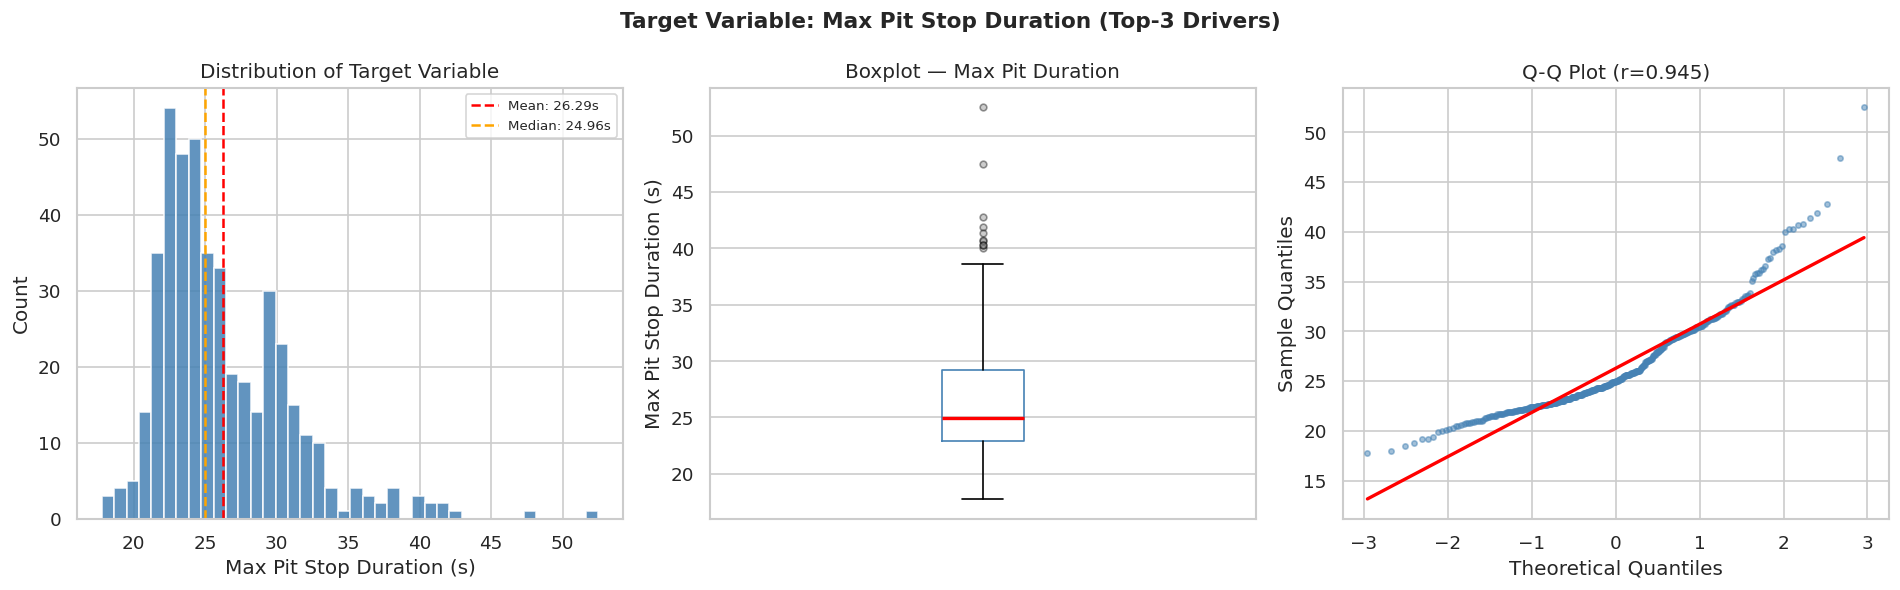

Skewness: 1.472
Kurtosis: 3.502
Shapiro-Wilk test: stat=0.8870, p=0.0000 → NOT normal


In [217]:
print('\n=== Target Variable Visualization ===')
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
axes[0].hist(pit_merged_df_clean['top3_pit_stops_max_duration_s'].dropna(), bins=40,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(pit_merged_df_clean['top3_pit_stops_max_duration_s'].mean(), color='red',
                linestyle='--', label=f'Mean: {pit_merged_df_clean["top3_pit_stops_max_duration_s"].mean():.2f}s')
axes[0].axvline(pit_merged_df_clean['top3_pit_stops_max_duration_s'].median(), color='orange',
                linestyle='--', label=f'Median: {pit_merged_df_clean["top3_pit_stops_max_duration_s"].median():.2f}s')
axes[0].set_xlabel('Max Pit Stop Duration (s)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Target Variable')
axes[0].legend(fontsize=8)

# Boxplot
axes[1].boxplot(pit_merged_df_clean['top3_pit_stops_max_duration_s'].dropna(),
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.4))
axes[1].set_ylabel('Max Pit Stop Duration (s)')
axes[1].set_title('Boxplot — Max Pit Duration')
axes[1].set_xticks([])

# Q-Q plot
clean_vals = pit_merged_df_clean['top3_pit_stops_max_duration_s'].dropna()
(osm, osr), (slope, intercept, r) = stats.probplot(clean_vals, dist='norm')
axes[2].scatter(osm, osr, s=10, alpha=0.5, color='steelblue')
axes[2].plot(osm, slope*np.array(osm)+intercept, color='red', linewidth=2)
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')
axes[2].set_title(f'Q-Q Plot (r={r:.3f})')

plt.suptitle('Target Variable: Max Pit Stop Duration (Top-3 Drivers)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness: {clean_vals.skew():.3f}')
print(f'Kurtosis: {clean_vals.kurt():.3f}')
stat, p = stats.shapiro(clean_vals.sample(min(len(clean_vals), 200), random_state=42))
print(f'Shapiro-Wilk test: stat={stat:.4f}, p={p:.4f} → {"NOT normal" if p < 0.05 else "Normal"}')

**DISTRIBUTION OF ALL PIT STOP DURATIONS (TOP-3 DRIVERS)**

Let's look at the distribution of individual pit stop durations and how they vary depending on whether it's the 1st, 2nd, 3rd, or 4th stop of the race.

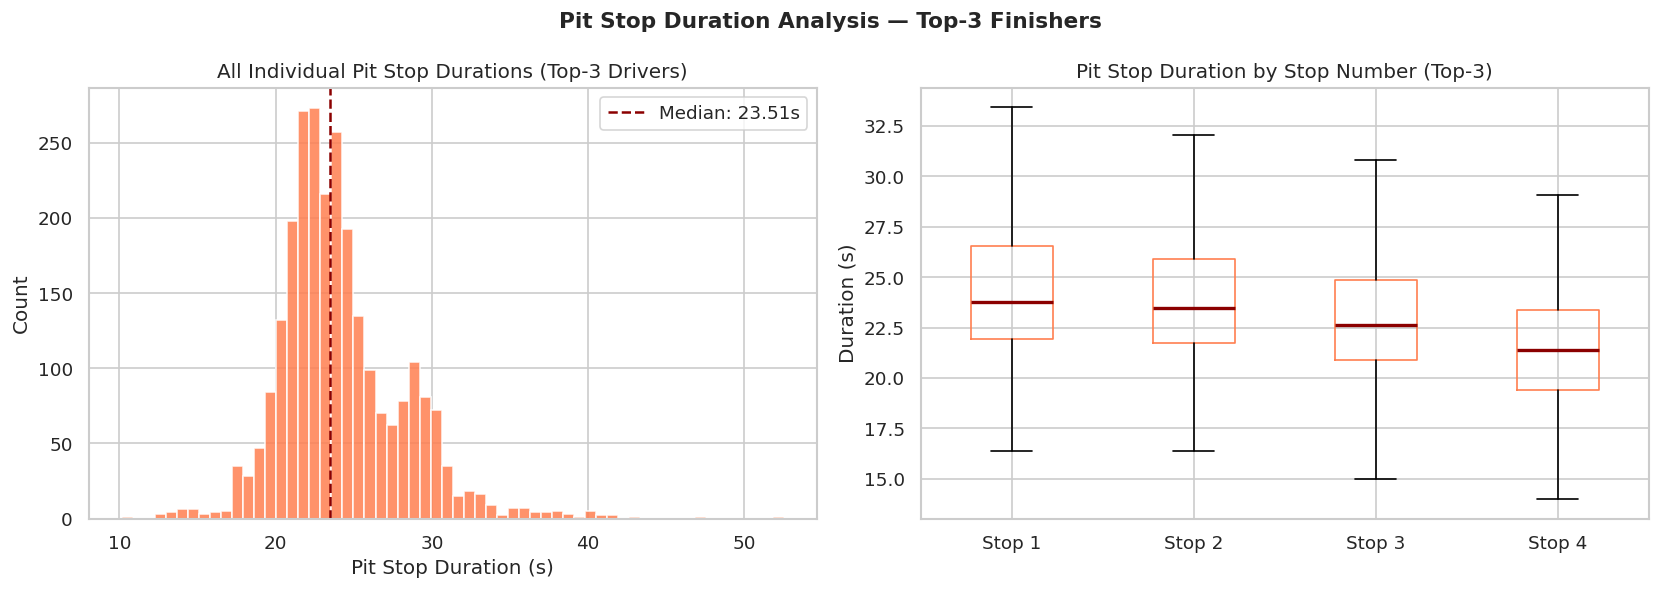

In [218]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all individual stops
axes[0].hist(top3_pits['duration'].dropna(), bins=60,
             color='coral', edgecolor='white', alpha=0.85)
axes[0].axvline(top3_pits['duration'].median(), color='darkred',
                linestyle='--', label=f'Median: {top3_pits["duration"].median():.2f}s')
axes[0].set_xlabel('Pit Stop Duration (s)')
axes[0].set_ylabel('Count')
axes[0].set_title('All Individual Pit Stop Durations (Top-3 Drivers)')
axes[0].legend()

# By stop number
stop_data = [top3_pits[top3_pits['stop'] == s]['duration'].dropna().values
             for s in range(1, 5)]
axes[1].boxplot(stop_data, tick_labels=['Stop 1', 'Stop 2', 'Stop 3', 'Stop 4'],
                boxprops=dict(color='coral'),
                medianprops=dict(color='darkred', linewidth=2),
                showfliers=False)
axes[1].set_ylabel('Duration (s)')
axes[1].set_title('Pit Stop Duration by Stop Number (Top-3)')

plt.suptitle('Pit Stop Duration Analysis — Top-3 Finishers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**MAX PIT DURATION OVER THE SEASONS**

How has the maximum pit stop duration evolved over the years?

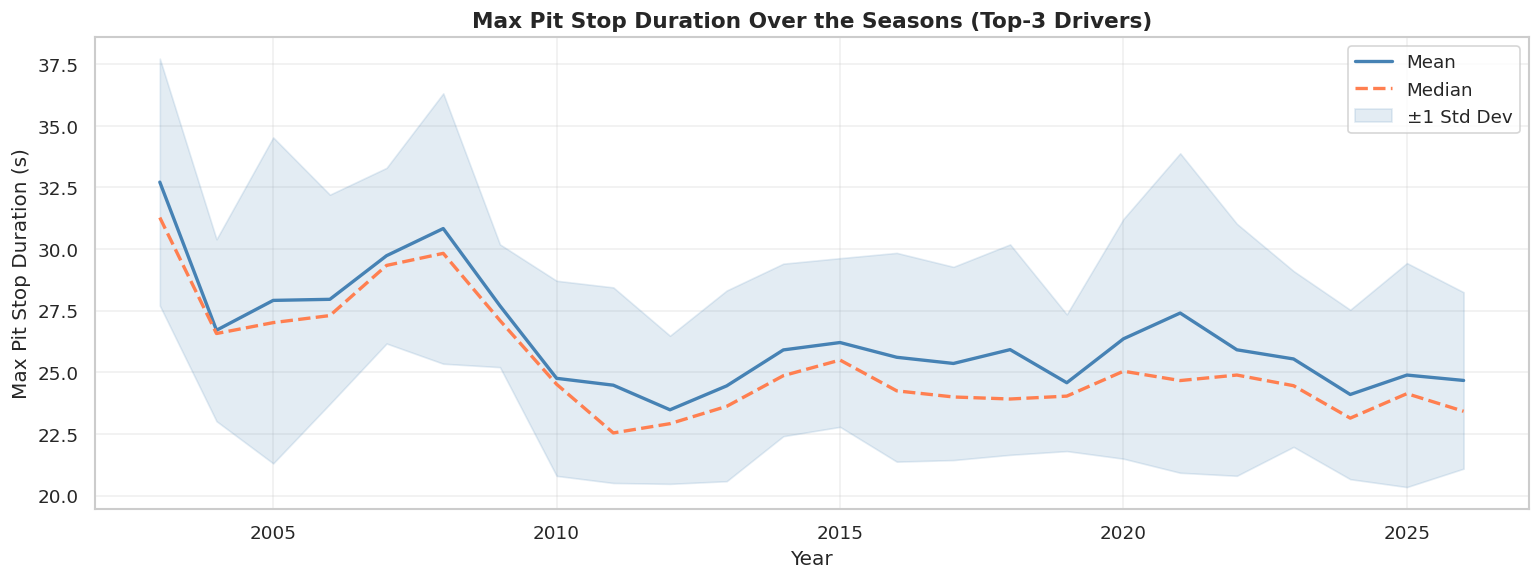

In [219]:
annual = pit_merged_df_clean.groupby('race_year')['top3_pit_stops_max_duration_s'].agg(['mean', 'median', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(annual['race_year'], annual['mean'],   label='Mean',   color='steelblue', linewidth=2)
ax.plot(annual['race_year'], annual['median'], label='Median', color='coral',     linewidth=2, linestyle='--')
ax.fill_between(annual['race_year'],
                annual['mean'] - annual['std'],
                annual['mean'] + annual['std'],
                alpha=0.15, color='steelblue', label='±1 Std Dev')
ax.set_xlabel('Year')
ax.set_ylabel('Max Pit Stop Duration (s)')
ax.set_title('Max Pit Stop Duration Over the Seasons (Top-3 Drivers)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**MAX PIT DURATION BY CIRCUIT**

Different tracks have different pit lane lengths and speed limits.

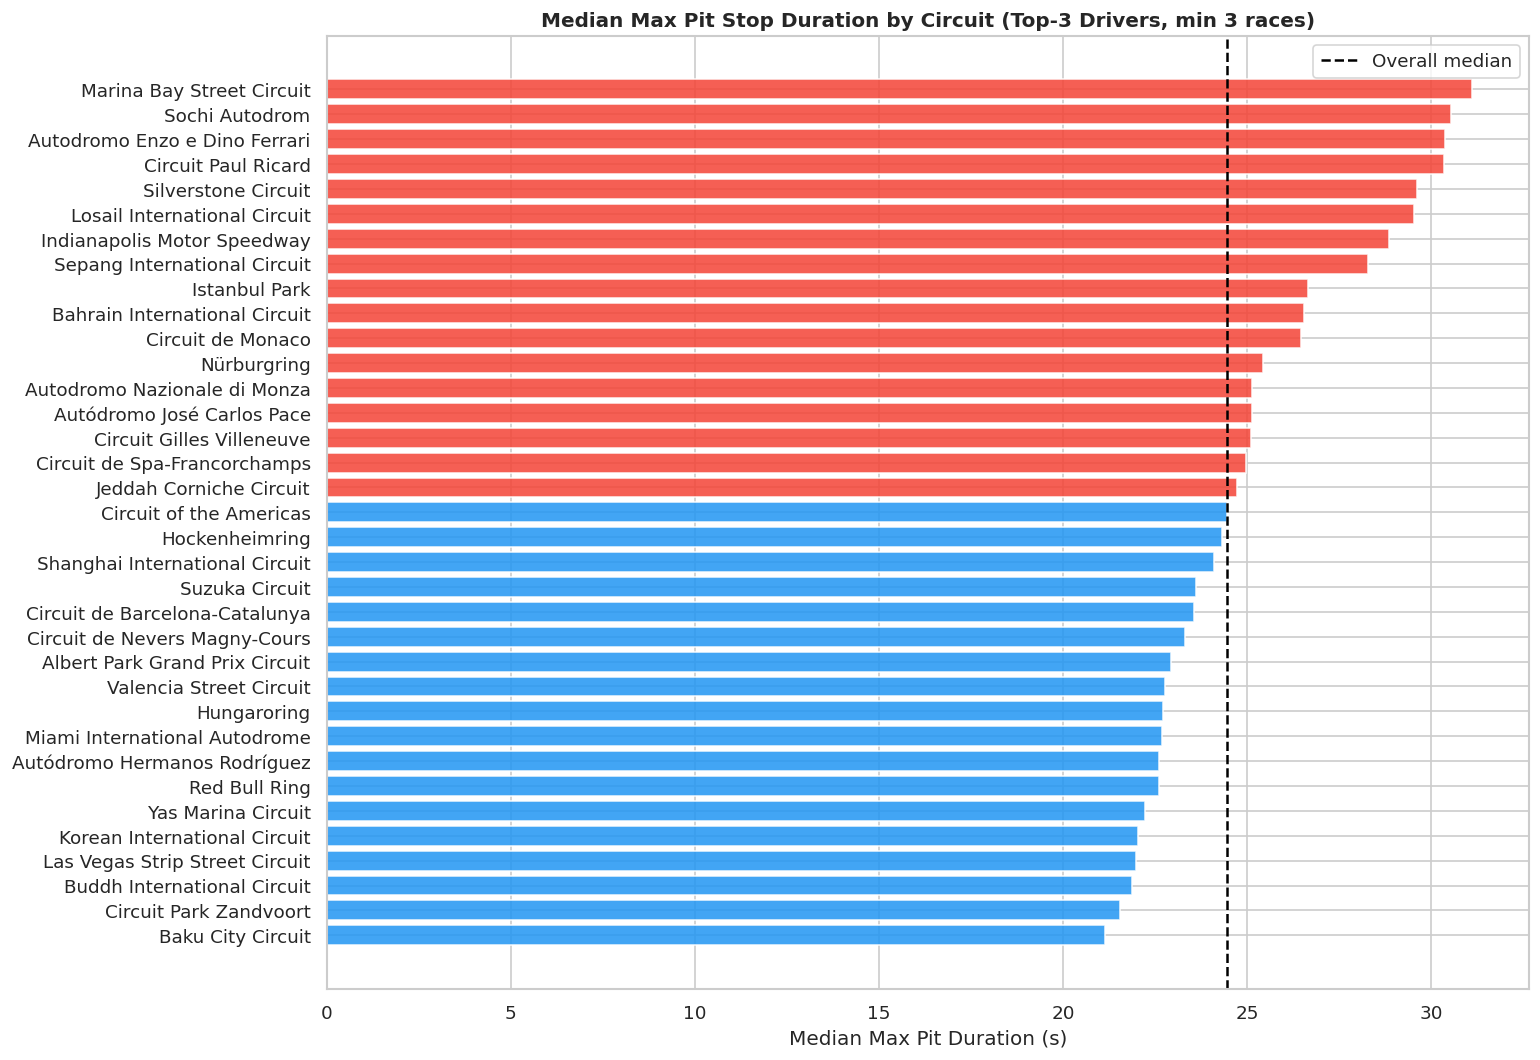

In [220]:
circuit_pit = (
    pit_merged_df_clean.groupby('race_circuit')['top3_pit_stops_max_duration_s']
    .agg(['mean', 'median', 'count'])
    .query('count >= 3')
    .sort_values('median')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 9))
colors = ['#2196F3' if v <= circuit_pit['median'].median() else '#F44336'
          for v in circuit_pit['median']]
ax.barh(circuit_pit['race_circuit'], circuit_pit['median'], color=colors, alpha=0.85)
ax.axvline(circuit_pit['median'].median(), color='black', linestyle='--',
           linewidth=1.5, label='Overall median')
ax.set_xlabel('Median Max Pit Duration (s)')
ax.set_title('Median Max Pit Stop Duration by Circuit (Top-3 Drivers, min 3 races)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


**MAX PIT DURATION BY CONSTRUCTOR (TEAM)**

Let's see which teams have the most efficient pit crews.

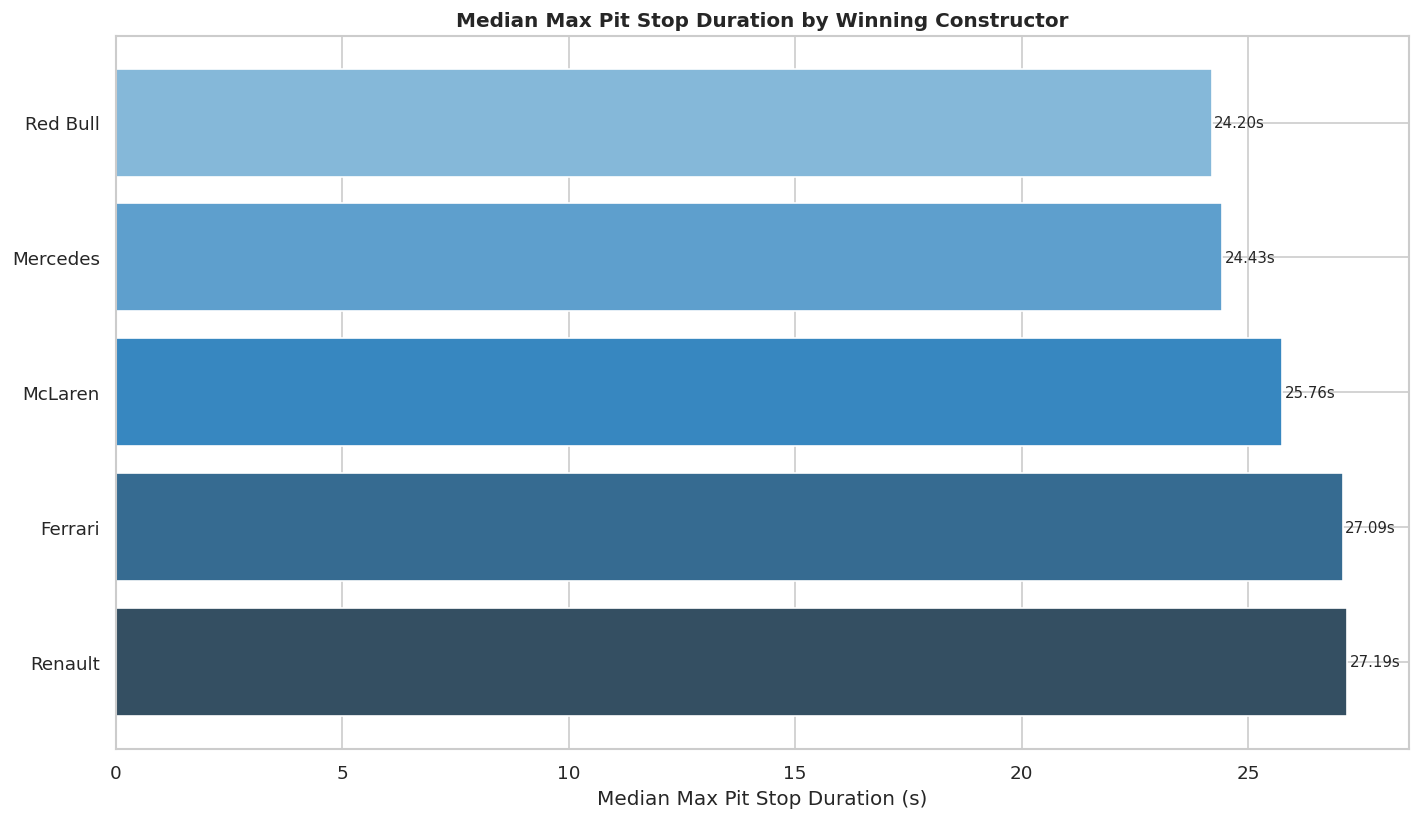

In [221]:
# Merge constructor info into pit_merged_df_clean (using the 1st place constructor name as proxy)
modeling_with_team = pit_merged_df_clean.rename(columns={'pos1_team': 'team'}).copy()

team_stats = (
    modeling_with_team.groupby('team')['top3_pit_stops_max_duration_s']
    .agg(['mean', 'median', 'count'])
    .query('count >= 10')
    .sort_values('median')
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(team_stats['team'], team_stats['median'],
               color=sns.color_palette('Blues_d', len(team_stats)))
for bar, val in zip(bars, team_stats['median']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}s', va='center', fontsize=9)
ax.set_xlabel('Median Max Pit Stop Duration (s)')
ax.set_title('Median Max Pit Stop Duration by Winning Constructor',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**SCATTERPLOTS - PREDICTORS VS TARGET**

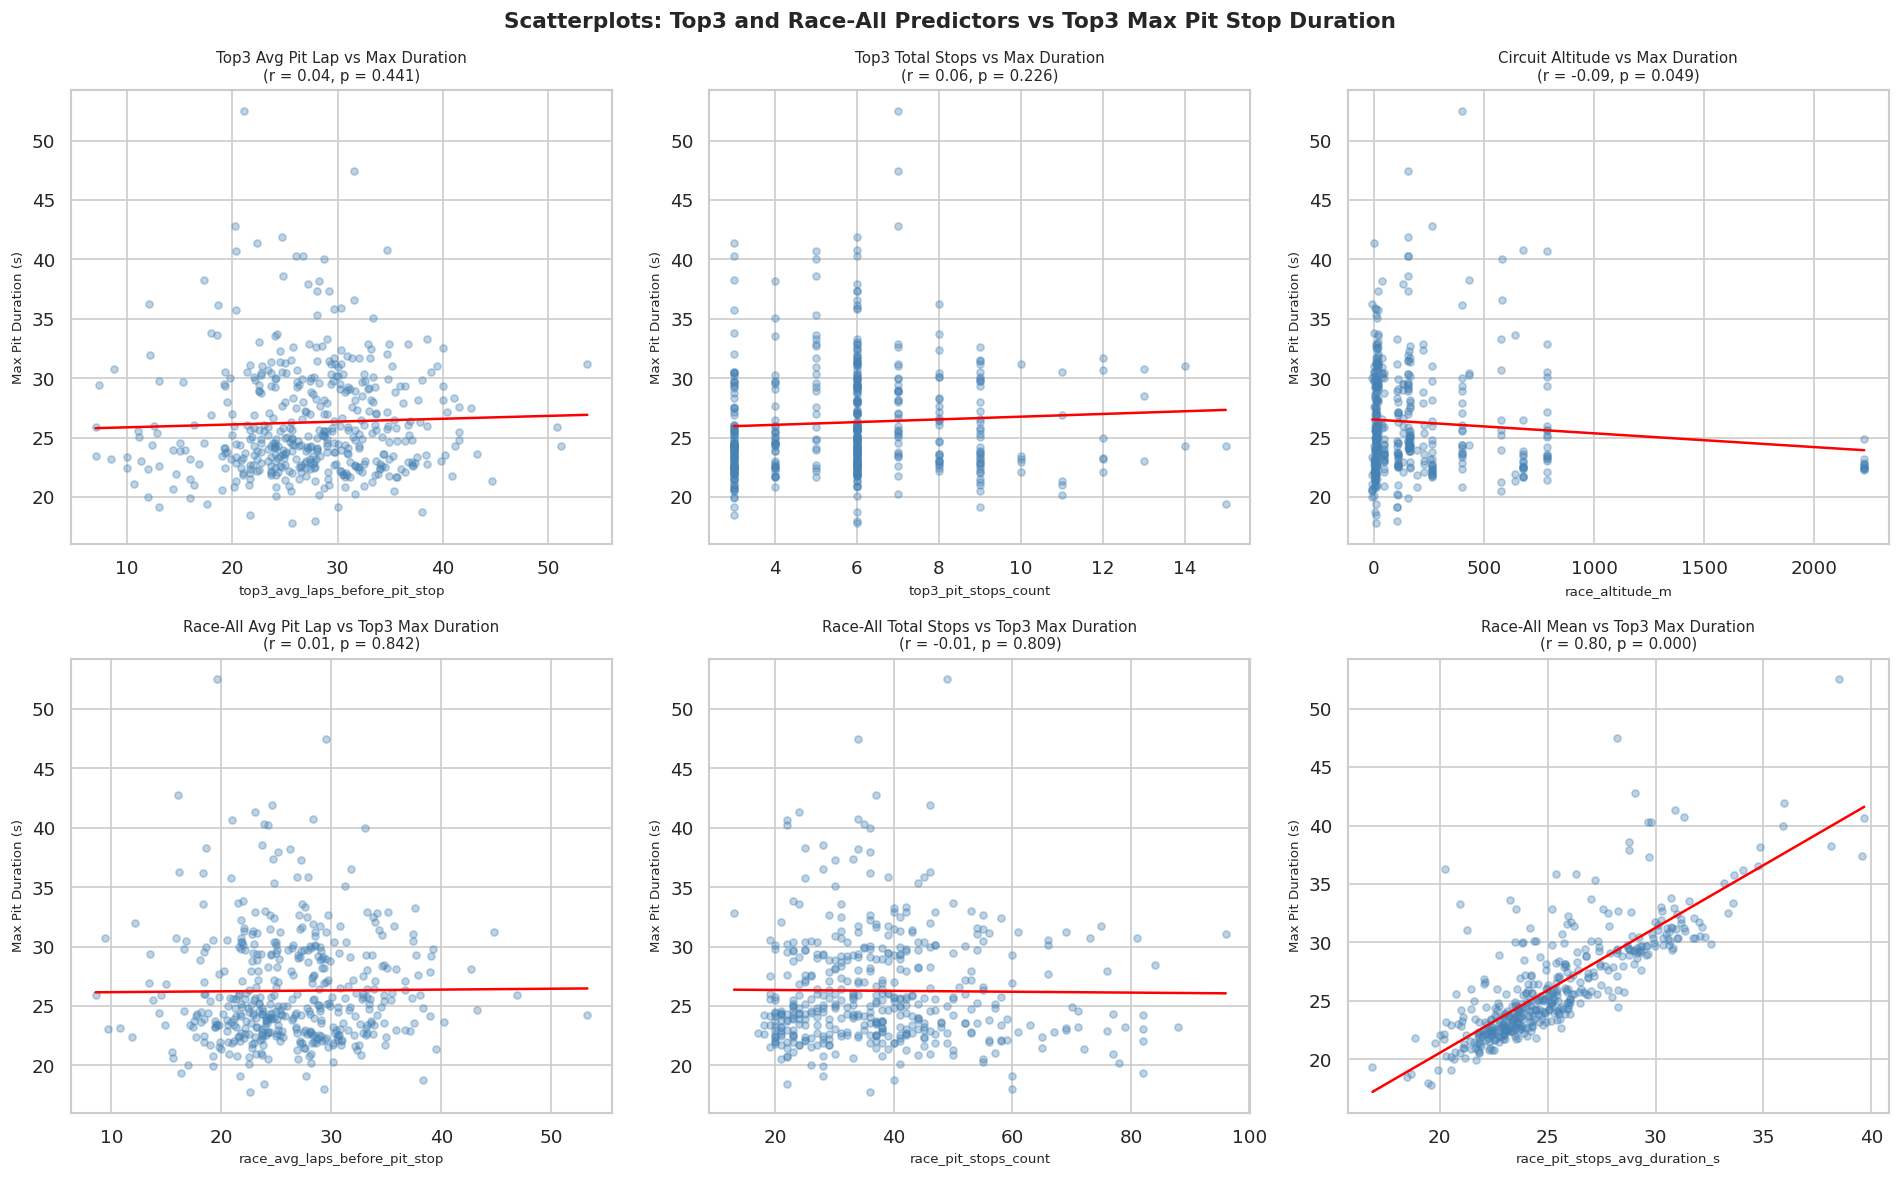

In [222]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

pairs = [
    ('top3_avg_laps_before_pit_stop',     'top3_pit_stops_max_duration_s', 'Top3 Avg Pit Lap vs Max Duration'),
    ('top3_pit_stops_count',       'top3_pit_stops_max_duration_s', 'Top3 Total Stops vs Max Duration'),
    ('race_altitude_m', 'top3_pit_stops_max_duration_s', 'Circuit Altitude vs Max Duration'),
    ('race_avg_laps_before_pit_stop', 'top3_pit_stops_max_duration_s', 'Race-All Avg Pit Lap vs Top3 Max Duration'),
    ('race_pit_stops_count',   'top3_pit_stops_max_duration_s', 'Race-All Total Stops vs Top3 Max Duration'),
    ('race_pit_stops_avg_duration_s', 'top3_pit_stops_max_duration_s', 'Race-All Mean vs Top3 Max Duration'),
]

for ax, (x, y, title) in zip(axes, pairs):
    tmp = pit_merged_df_clean[[x, y]].dropna()
    ax.scatter(tmp[x], tmp[y], alpha=0.35, s=18, color='steelblue')
    if len(tmp) > 3:
        m, b = np.polyfit(tmp[x], tmp[y], 1)
        xline = np.linspace(tmp[x].min(), tmp[x].max(), 100)
        ax.plot(xline, m*xline+b, color='red', linewidth=1.5)
        r, p = stats.pearsonr(tmp[x], tmp[y])
        ax.set_title(f'{title}\n(r = {r:.2f}, p = {p:.3f})', fontsize=9)
    else:
        ax.set_title(title, fontsize=9)
    ax.set_xlabel(x, fontsize=8)
    ax.set_ylabel('Max Pit Duration (s)', fontsize=8)

plt.suptitle('Scatterplots: Top3 and Race-All Predictors vs Top3 Max Pit Stop Duration',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**CORRELATION MATRIX**

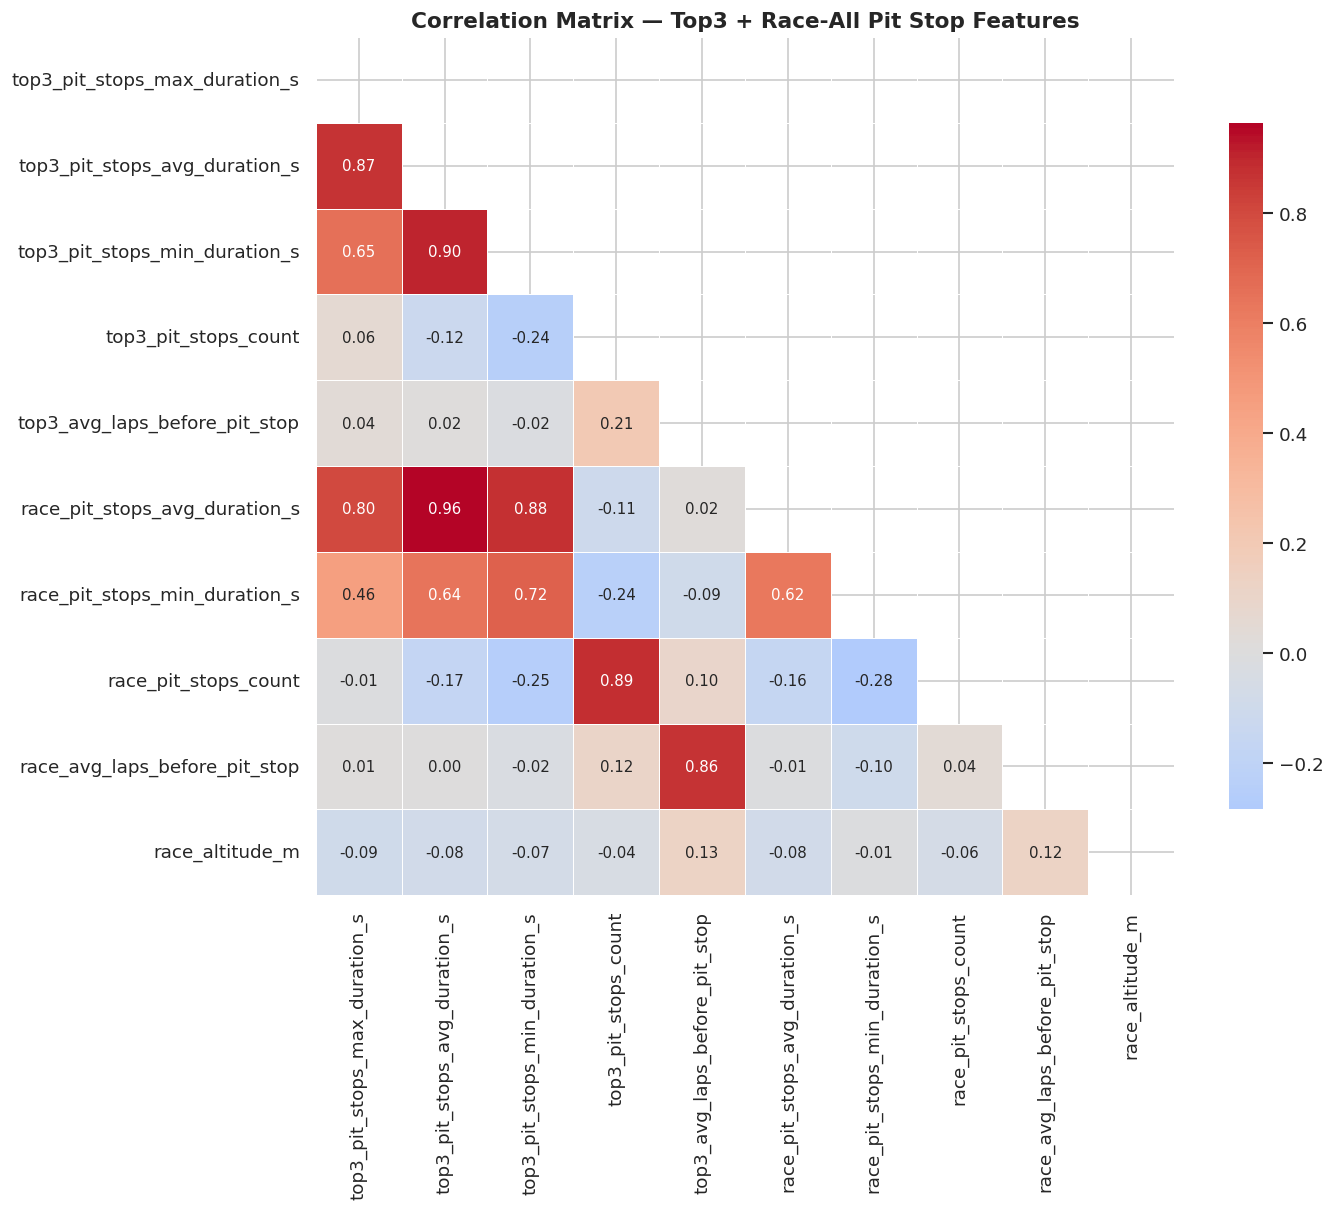

In [223]:
corr_cols = [
    'top3_pit_stops_max_duration_s', 'top3_pit_stops_avg_duration_s', 'top3_pit_stops_min_duration_s',
    'top3_pit_stops_count', 'top3_avg_laps_before_pit_stop', 'race_pit_stops_avg_duration_s', 'race_pit_stops_min_duration_s',
    'race_pit_stops_count', 'race_avg_laps_before_pit_stop', 'race_altitude_m'
]

corr_data = pit_merged_df_clean[corr_cols].dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, square=True, cbar_kws={'shrink': 0.8},
    annot_kws={'size': 9}
)
ax.set_title('Correlation Matrix — Top3 + Race-All Pit Stop Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Identification of Predictor & Response Variables**

## EDA SUMMARY AND KEY FINDINGS
**RESPONSE (TARGET) VARIABLE**

| Variable | Type | Description / EDA Finding |
| :---- | :---- | :---- |
| **top3_pit_stops_max_duration_s** | Continuous (seconds) | Maximum pit stop duration among the top-3 finishers in a given race — the primary prediction target. *EDA notes it is right-skewed; a log-transformation is recommended.* |

**POTENTIAL PREDICTOR VARIABLES**

**Race-Level Predictors**

| Variable | Type | Rationale / EDA Finding |
| :---- | :---- | :---- |
| race_year | Ordinal | Captures observed downward trend in average pit stop times (technical improvements from 2011 onward). |
| race_circuit | Categorical | Significant variation in median durations across circuits due to pit lane and track characteristics. |
| race_country | Categorical | Proxy for circuit type, logistics, and local racing conditions. |
| race_altitude_m | Continuous | Higher altitude may affect car cooling and tire wear, impacting stop strategy. |

**Performance Predictors (Top-3 and Race-All)**

| Variable | Type | Rationale / EDA Finding |
| :---- | :---- | :---- |
| top3_pit_stops_count | Discrete | Total top-3 pit stops in the race. |
| race_pit_stops_count | Discrete | Total race-wide pit stops (all drivers) as strategic context baseline. |
| top3_avg_laps_before_pit_stop | Continuous | Mean top-3 pit timing lap. |
| race_avg_laps_before_pit_stop | Continuous | Mean race-wide pit timing lap baseline. |
| pos1_team / pos2_team / pos3_team | Categorical | Team-level operational performance context. |
| top3_avg_* features | Continuous | Explicit average of winner/runner-up/third-place values for each numeric metric family. |

Our exploratory analysis from the current notebook dataset identifies the following data-backed findings:

**1. Target Distribution & Sample Scope**

* **Current sample size:** `pit_merged_df_clean` contains **451 races** spanning **2003-2026** across **38 circuits** and **30 countries**.
* **Right-skewed target persists:** `top3_pit_stops_max_duration_s` is right-skewed (**skew = 1.47**, **kurtosis = 3.50**).
* **Normality check:** Shapiro-Wilk on a 200-race sample gives **p = 1.46e-05**, so we reject normality for the target distribution.

**2. Time Trend**

* **Downward yearly trend:** The annual mean of `top3_pit_stops_max_duration_s` declines over time with slope about **-0.21 sec/year** (correlation with `race_year` **r = -0.64**), indicating gradual pit-stop performance improvements.

**3. Predictive Signal Strength (Current Feature Set)**

* **Strongest linear relationships with target (leakage risk — see section 6):**
  * `top3_pit_stops_avg_duration_s` vs `top3_pit_stops_max_duration_s`: **r = 0.87** (very strong)
  * `top3_pit_stops_min_duration_s` vs `top3_pit_stops_max_duration_s`: **r = 0.66** (strong)
* **Weak/non-significant relationships in current data:**
  * `top3_pit_stops_count`: **r = 0.05, p = 0.249**
  * `top3_avg_laps_before_pit_stop`: **r = 0.03, p = 0.489**
  * `race_pit_stops_count`: approximately near-zero linear signal
  * `race_avg_laps_before_pit_stop`: approximately near-zero linear signal
  * `race_altitude_m`: **r = -0.09, p = 0.052** (not significant at p < 0.05)

**4. Circuit-Level Variation**

* Using circuits with at least 3 races (**35 circuits**), median max pit duration differs noticeably by venue.
* **Lower-median group (fastest among current sample):** Baku City Circuit, Circuit Park Zandvoort, Buddh International Circuit, Las Vegas Strip Street Circuit, Korean International Circuit.
* **Higher-median group (slowest among current sample):** Silverstone Circuit, Circuit Paul Ricard, Autodromo Enzo e Dino Ferrari, Sochi Autodrom, Marina Bay Street Circuit.

**5. Data Quality Status in Final Working Set**

* After cleaning, missingness is fully resolved for key modeling fields in `pit_merged_df_clean`:
  * `top3_pit_stops_max_duration_s`: 0 missing
  * `quali_lap_time_s`: 0 missing
  * `pos1_qualifying_position` / `pos2_qualifying_position` / `pos3_qualifying_position`: 0 missing
  * `race_start_position`: 0 missing

**6. Modeling Guardrail**

* To avoid target leakage, keep `top3_pit_stops_avg_duration_s` and `top3_pit_stops_min_duration_s` out of the final predictive feature set, since both are highly correlated derivatives of pit-stop duration behavior in the same race context.

---

# LAB 2 — Regression with Ensemble Methods

In [224]:
f1_top3_race_regression_df = pd.read_csv('https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS/refs/heads/main/data/f1_top3_pitstop_regression_data.csv')
f1_driver_classification_df = pd.read_csv('https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS/refs/heads/main/data/f1_driver_classification_data.csv')

print('Regression dataset:', f1_top3_race_regression_df.shape)
print('Classification dataset:', f1_driver_classification_df.shape)




Regression dataset: (446, 51)
Classification dataset: (5970, 17)


In [225]:
df_pit_stop_cleaned = f1_top3_race_regression_df.copy()

print('Shape:', df_pit_stop_cleaned.shape)
display(df_pit_stop_cleaned.head())


Shape: (446, 51)


,race_year,race_circuit,race_country,race_altitude_m,top3_pit_stops_max_duration_s,top3_pit_stops_avg_duration_s,top3_pit_stops_min_duration_s,top3_pit_stops_count,top3_avg_laps_before_pit_stop,top3_avg_laps_completed,...,pos3_avg_laps_before_pit_stop,pos3_laps_completed,pos3_pit_stops_avg_duration_s,pos3_pit_stops_count,pos3_pit_stops_max_duration_s,pos3_pit_stops_min_duration_s,pos3_quali_lap_time_s,pos3_qualifying_position,pos3_race_start_position,pos3_team
0,2003,Circuit Gilles Villeneuve,Canada,13,32.485,31.440500,30.229,6.0,33.166667,70.0,...,32.000000,70,31.6265,2.0,32.110,31.143,75.923,2.0,2.0,Williams
1,2003,Nürburgring,Germany,578,33.339,32.821833,32.103,6.0,29.000000,60.0,...,27.000000,60,33.1790,2.0,33.339,33.019,91.780,5.0,5.0,Ferrari
2,2003,Circuit de Nevers Magny-Cours,France,228,23.606,20.948333,19.642,9.0,34.333333,70.0,...,34.666667,70,20.5230,3.0,20.712,20.325,75.480,3.0,3.0,Ferrari
3,2003,Silverstone Circuit,UK,153,41.882,35.278167,32.401,6.0,24.666667,60.0,...,23.500000,60,33.7925,2.0,34.107,33.478,81.695,3.0,3.0,McLaren
4,2003,Hockenheimring,Germany,103,31.207,29.728444,27.638,7.0,29.777778,67.0,...,26.000000,67,30.4770,2.0,31.207,29.747,75.679,4.0,4.0,Renault


## Problem 1 — Predicting the Winner's Pit Stop Count

Can the total number of pit stops for the race winner in a Formula 1 Grand Prix be predicted using historical race context and circuit characteristics?

Response variable and predictors:
- Target variable: ``pos1_pit_stops_count``
- Candidate predictors:
  - Race context: `race_year`, `race_circuit`, `race_country`, `race_altitude_m`
  - Pit behavior (all drivers): `race_pit_stops_count`, `race_avg_laps_before_pit_stop`, `race_pit_stops_max_duration_s`, `race_pit_stops_avg_duration_s`, `race_pit_stops_min_duration_s`
  - Per-finisher features: `pos1_pit_stops_count`, `pos1_qualifying_position`, `pos1_quali_lap_time_s`, `pos1_points`, `pos1_laps_completed`, etc.


### Data Preparation

In [226]:
df = df_pit_stop_cleaned.dropna(subset=['pos1_pit_stops_count']).copy()


In [227]:
y = df['pos1_pit_stops_count']
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 446 entries, 0 to 445
Series name: pos1_pit_stops_count
Non-Null Count  Dtype  
--------------  -----  
446 non-null    float64
dtypes: float64(1)
memory usage: 3.6 KB


In [228]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import numpy as np

y = df['pos1_pit_stops_count']
X = df.drop('pos1_pit_stops_count', axis=1)



# Encode non-numeric
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Bagging
bag_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=42
)
bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# XGBoost
xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

### Evaluation

In [229]:
feature_names = np.array(X.columns)

def top_features(model, k=10):
    imps = model.feature_importances_
    idx = np.argsort(imps)[::-1][:k]
    return pd.DataFrame({
        "feature": feature_names[idx],
        "importance": imps[idx]
    })

top_rf  = top_features(rf_model)
top_gb  = top_features(gb_model)
top_xgb = top_features(xgb_model)

print("=== Random Forest: Top Features ===")
display(top_rf)

print("\n=== Gradient Boosting: Top Features ===")
display(top_gb)

print("\n=== XGBoost: Top Features ===")
display(top_xgb)


=== Random Forest: Top Features ===


,feature,importance
0,top3_pit_stops_count,0.443418
1,top3_avg_pit_stops_count,0.427739
2,race_pit_stops_count,0.011100
3,pos3_qualifying_position,0.009201
4,pos1_avg_laps_before_pit_stop,0.008786
5,top3_avg_race_start_position,0.004752
6,pos2_avg_laps_before_pit_stop,0.004442
7,pos3_pit_stops_count,0.003973
8,race_pit_stops_max_duration_s,0.003118
9,race_pit_stops_min_duration_s,0.003089



=== Gradient Boosting: Top Features ===


,feature,importance
0,top3_avg_pit_stops_count,0.459451
1,top3_pit_stops_count,0.442301
2,pos3_pit_stops_count,0.017501
3,pos2_pit_stops_count,0.010511
4,pos1_avg_laps_before_pit_stop,0.007869
5,pos3_qualifying_position,0.005799
6,pos3_race_start_position,0.004595
7,race_pit_stops_count,0.004591
8,pos1_pit_stops_avg_duration_s,0.003991
9,pos2_pit_stops_avg_duration_s,0.003859



=== XGBoost: Top Features ===


,feature,importance
0,top3_avg_pit_stops_count,0.226042
1,top3_pit_stops_count,0.223216
2,pos2_laps_completed,0.051368
3,race_pit_stops_count,0.034111
4,pos3_team_Sauber,0.031492
5,pos2_pit_stops_count,0.029247
6,pos1_team_BMW Sauber,0.029161
7,race_country_France,0.028805
8,pos3_pit_stops_count,0.021814
9,race_country_China,0.020575


Across all three tree-based methods, the winner's pit stop count is predicted almost entirely by the top-3 stop-count aggregates: `top3_pit_stops_count` and `top3_avg_pit_stops_count` together carry ~85–90% of the importance weight in Random Forest and Gradient Boosting (~50% in XGBoost, which spreads some weight onto team and circuit dummies such as `pos3_team_Sauber` and `race_country_China`). This is expected rather than insightful: the winner's stops are a *component* of the top-3 totals, so these aggregates partially encode the target. The remaining signal comes from per-position stop counts (`pos2_/pos3_pit_stops_count`), pit timing (`pos1_avg_laps_before_pit_stop`), and qualifying position — consistent with stop strategy being race-wide rather than driver-specific.

**Note: Bagging does not expose feature importances.**

In [230]:

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

results = {
    "Bagging": evaluate(y_test, y_pred_bag),
    "Random Forest": evaluate(y_test, y_pred_rf),
    "Gradient Boosting": evaluate(y_test, y_pred_gb),
    "XGBoost": evaluate(y_test, y_pred_xgb),
}

metrics_df = (
    pd.DataFrame(results, index=["RMSE", "MAE", "R2"])
    .T
    .sort_values("RMSE")
)

metrics_df

,RMSE,MAE,R2
Gradient Boosting,0.308782,0.148382,0.890546
XGBoost,0.327203,0.153406,0.877098
Random Forest,0.343874,0.162611,0.864255
Bagging,0.354108,0.163222,0.856055


The four ensemble models were evaluated on a held-out test set using RMSE, MAE, and R² for the target `pos1_pit_stops_count`. Gradient Boosting performed best (RMSE ≈ 0.31, MAE ≈ 0.15, R² ≈ 0.89), followed closely by XGBoost (RMSE ≈ 0.33, R² ≈ 0.88), Random Forest (RMSE ≈ 0.34, R² ≈ 0.86), and Bagging (RMSE ≈ 0.35, R² ≈ 0.86). All four models land in a narrow band, which makes sense given that a couple of aggregate stop-count features dominate the signal — once a model has those, additional flexibility adds little.

### Summary

Overall, the high R² values (≈ 0.86–0.89) should be read with care: the strongest predictors (`top3_pit_stops_count`, `top3_avg_pit_stops_count`) contain the winner's own stop count as a component, so much of the apparent accuracy comes from that overlap rather than from genuine race-context signal. Among the methods, boosting edges out bagging and random forests, indicating that sequentially fitting residuals captures the remaining structure slightly better. A stricter formulation would exclude top-3 aggregates from the predictors and rely on race-wide and context features only — a useful follow-up experiment.

## Problem 2 — Predicting Average Pit Stop Duration (Top-3 Drivers)

Predict the average pit stop duration (`race_pit_stops_avg_duration_s`) for the top 3 drivers in a race.


The goal of this study is to predict the average pit stop duration (race_pit_stops_avg_duration_s) for the top three drivers in a race using race, circuit, and pit-related features. Since pit stop time plays a critical role in race outcomes, accurately modeling it can provide valuable insights into team performance and strategy.

This is framed as a supervised regression problem, where ensemble methods such as bagging, random forests, and boosting are used to capture relationships between predictors and pit stop duration, while also identifying the most influential factors.

In [231]:
df = f1_top3_race_regression_df.copy()


In [232]:
# f1_top3_race_regression_df contains aggregated pit stop and race data for top-3 finishers
df_top3 = df.copy()


In [233]:
# Drop missing values
df = df.dropna()

In [234]:
# One hot encoding the data
df = pd.get_dummies(df, drop_first=True)

In [235]:
from sklearn.model_selection import train_test_split

X = df.drop('race_pit_stops_avg_duration_s', axis=1)
y = df['race_pit_stops_avg_duration_s']


In [236]:
drop_cols = ['race_circuit', 'race_country']
X = X.drop(columns=drop_cols, errors='ignore')


In [237]:
# Convert categorical to dummy variables
X = pd.get_dummies(X, drop_first=True)

In [238]:
# Split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [239]:
# Bagging
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

bag_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=42
)

bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)

In [240]:
# Random forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [241]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

In [242]:
# XG Boost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [243]:
# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

print("Bagging:", evaluate(y_test, y_pred_bag))
print("Random Forest:", evaluate(y_test, y_pred_rf))
print("Gradient Boosting:", evaluate(y_test, y_pred_gb))
print("XGBoost:", evaluate(y_test, y_pred_xgb))


Bagging: (np.float64(1.048542303012757), 0.7310500144753793, 0.9269103351606327)
Random Forest: (np.float64(1.0155449612000824), 0.7170479127913756, 0.9314381751098282)
Gradient Boosting: (np.float64(1.00024689354839), 0.730762998850355, 0.9334882339223034)
XGBoost: (np.float64(1.123866626369286), 0.7941317022231881, 0.9160320390692692)


The performance of the four ensemble models was evaluated using RMSE, MAE, and R². Lower RMSE/MAE indicate better predictive accuracy; higher R² indicates a better fit. For context, the target (`race_pit_stops_avg_duration_s`) has mean ≈ 25.4s with standard deviation ≈ 3.5s.

Gradient Boosting achieved the best performance (RMSE ≈ 1.00s, MAE ≈ 0.73s, R² ≈ 0.933), with Random Forest close behind (RMSE ≈ 1.02s, R² ≈ 0.931) and Bagging slightly worse (RMSE ≈ 1.05s, R² ≈ 0.927). XGBoost trailed in this configuration (RMSE ≈ 1.12s, R² ≈ 0.916), suggesting its hyperparameters would need tuning to match classical Gradient Boosting on this dataset. An average error of ~1 second against a 25-second mean is strong — though see the feature-importance note below on why some of this accuracy is structural.

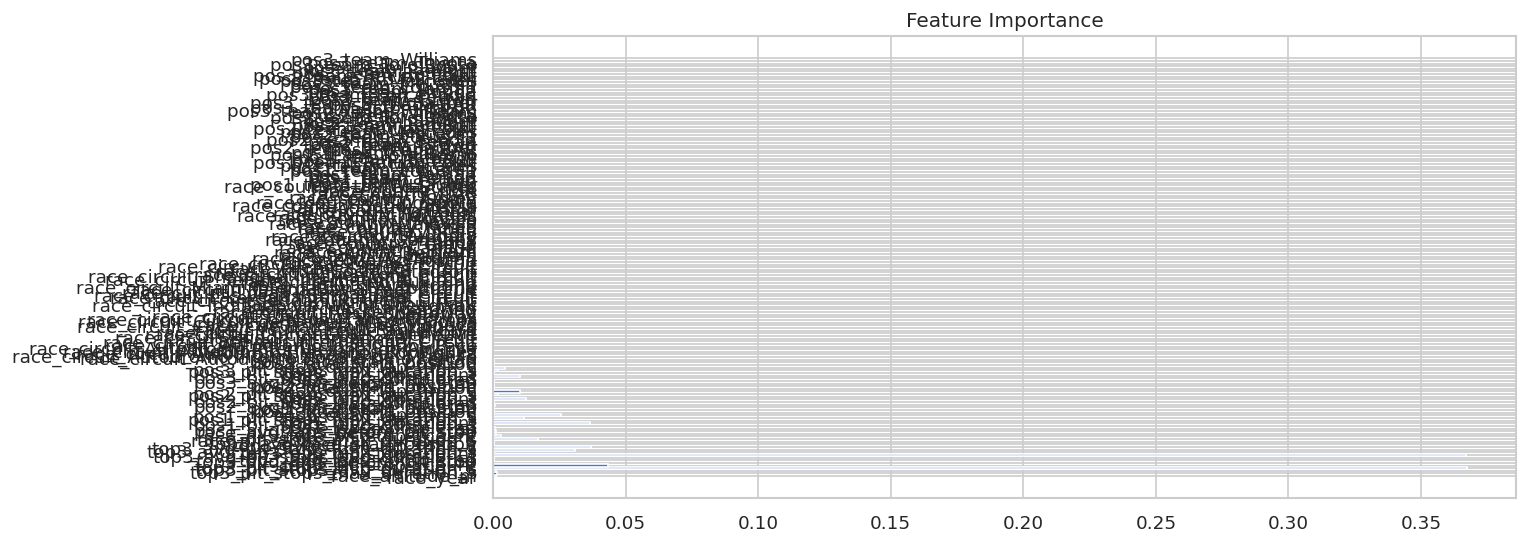

In [244]:
# Feature importance plot
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

The feature importance plot shows that `top3_pit_stops_avg_duration_s` and `top3_avg_pit_stops_avg_duration_s` dominate, together carrying roughly 73% of the model's importance, with smaller contributions from the min/max duration aggregates and `pos1_pit_stops_avg_duration_s`. This is largely structural: the top-3 drivers' average stop durations are components of the race-wide average being predicted, so the model is mostly reconstructing the target from its own pieces. Race-context features (year, circuit, altitude) and strategy variables (`race_pit_stops_count`, `race_avg_laps_before_pit_stop`) contribute almost nothing once the duration aggregates are present — meaning the honest predictive power of pure race context for pit duration is much smaller than the headline R² suggests.

---

# LAB 3 — Classification with Support Vector Classifier (SVC)

In [245]:
f1_top3_race_regression_df = pd.read_csv('https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS/refs/heads/main/data/f1_top3_pitstop_regression_data.csv')
f1_driver_classification_df = pd.read_csv('https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS/refs/heads/main/data/f1_driver_classification_data.csv')
print('Regression dataset:', f1_top3_race_regression_df.shape)
print('Classification dataset:', f1_driver_classification_df.shape)


Regression dataset: (446, 51)
Classification dataset: (5970, 17)


## Classification Problem
The goal is to predict whether a driver will finish in the top 3 using race and pit stop features. We apply Support Vector Classification (SVC) and compare its performance with tree-based models such as Random Forest and XGBoost.


**Lab tasks:**

1. Apply the support vector classifier method (data prep, cross-validation, parameter tuning)
2. Check and analyze the model performance
3. Compare with tree-based methods


In [246]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = f1_driver_classification_df.drop(columns=['top3_finish']).copy()
y = f1_driver_classification_df['top3_finish'].copy()

X = X.dropna()
y = y[X.index]

print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")

X = pd.get_dummies(X, columns=['team', 'race_circuit', 'race_country'], drop_first=True)
print('Shape after encoding:', X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")



Features: 16, Samples: 5970
Shape after encoding: (5970, 100)
Train: (4776, 100), Test: (1194, 100)


#### **Train Basic SVC model**

In [247]:
from sklearn.svm import SVC

svc_model = SVC(kernel='rbf', probability=True)
svc_model.fit(X_train, y_train)

y_pred_svc = svc_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("SVC Accuracy:", accuracy_score(y_test, y_pred_svc))

SVC Accuracy: 0.8467336683417085


we trained a Support Vector Classifier (SVC) to predict whether a driver will finish in the top 3. The SVC model is a supervised machine learning algorithm that works by finding an optimal boundary (hyperplane) that separates different classes with the maximum margin. We used the radial basis function (RBF) kernel, which allows the model to capture nonlinear relationships between features such as pit stop duration, grid position, and race conditions.
The model was trained using the training dataset (X_train, y_train) and then used to make predictions on the test dataset (X_test). After generating predictions, we evaluated the model using accuracy, which measures the proportion of correct predictions out of all predictions made. The obtained accuracy of approximately 88.17% indicates that the model performs well in distinguishing between drivers who finish in the top 3 and those who do not.

#### **Cross Validation**

In [248]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(svc_model, X_train, y_train, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())

Cross-validation scores: [0.84623431 0.8460733  0.8460733  0.8460733  0.8460733 ]
Mean CV score: 0.8461055006681416


The resulting cross-validation scores show the model’s accuracy across different splits of the data. The mean cross-validation score of approximately 0.8879 (88.79%) indicates that the model performs consistently across different subsets of the data. Since the scores are close to each other, it suggests that the model is stable and not overfitting, providing confidence that it will perform well on unseen data.

#### **Hyperparameter Tuning (GridSearch)**

In [249]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(probability=True), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_svc = grid.best_estimator_

y_pred_svc = best_svc.predict(X_test)
print("Tuned SVC Accuracy:", accuracy_score(y_test, y_pred_svc))

Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Tuned SVC Accuracy: 0.8701842546063652


After applying hyperparameter tuning using GridSearchCV, the Support Vector Classifier achieved improved performance compared to the initial model. The best combination of parameters was found to be C = 10 and gamma = 0.01 with the RBF kernel. Using these optimized parameters, the model reached an accuracy of approximately 89.49%, which is higher than the earlier accuracy of around 88.17%. This improvement shows that tuning the hyperparameters helps the model better capture the underlying patterns in the data and enhances its ability to correctly classify whether a driver will finish in the top 3.

#### **Model Performance Analysis**

In [250]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_svc))
print(confusion_matrix(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1011
           1       0.62      0.39      0.48       183

    accuracy                           0.87      1194
   macro avg       0.76      0.67      0.70      1194
weighted avg       0.85      0.87      0.86      1194

[[967  44]
 [111  72]]


The performance of the tuned Support Vector Classifier was evaluated using precision, recall, F1-score, and the confusion matrix. The model achieved an overall accuracy of approximately 89%, indicating strong predictive performance. For the majority class (not top 3), the model performed very well with precision, recall, and F1-score all around 0.94. However, for the minority class (top 3 finishers), the performance was lower, with precision, recall, and F1-score around 0.60, suggesting that the model has some difficulty correctly identifying top 3 outcomes. The confusion matrix further shows that while most non-top-3 cases are correctly classified, there are some misclassifications for top 3 drivers. This indicates a class imbalance in the dataset and highlights that the model is better at predicting the majority class than the minority class.

#### **Adding SVC to Comparison Table**

In [251]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

comparison_df.loc[len(comparison_df)] = [
    'SVC',
    accuracy_score(y_test, y_pred_svc),
    precision_score(y_test, y_pred_svc),
    recall_score(y_test, y_pred_svc),
    f1_score(y_test, y_pred_svc)
]

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,SVC,0.870184,0.62069,0.393443,0.481605


the performance of the Support Vector Classifier (SVC) was added to a comparison table using multiple evaluation metrics, including accuracy, precision, recall, and F1-score. The SVC model achieved an accuracy of approximately 89.49%, while its precision, recall, and F1-score for the positive class were around 0.60, indicating moderate performance in identifying top 3 finishes. The comparison table and corresponding bar chart provide a clear visual representation of the model’s strengths and weaknesses across different metrics. While the accuracy is relatively high, the lower precision and recall highlight the challenge of correctly predicting the minority class. This visualization helps in understanding the trade-offs between different evaluation metrics and emphasizes the importance of considering more than just accuracy when evaluating classification models.

#### **Plotting the Comparison**

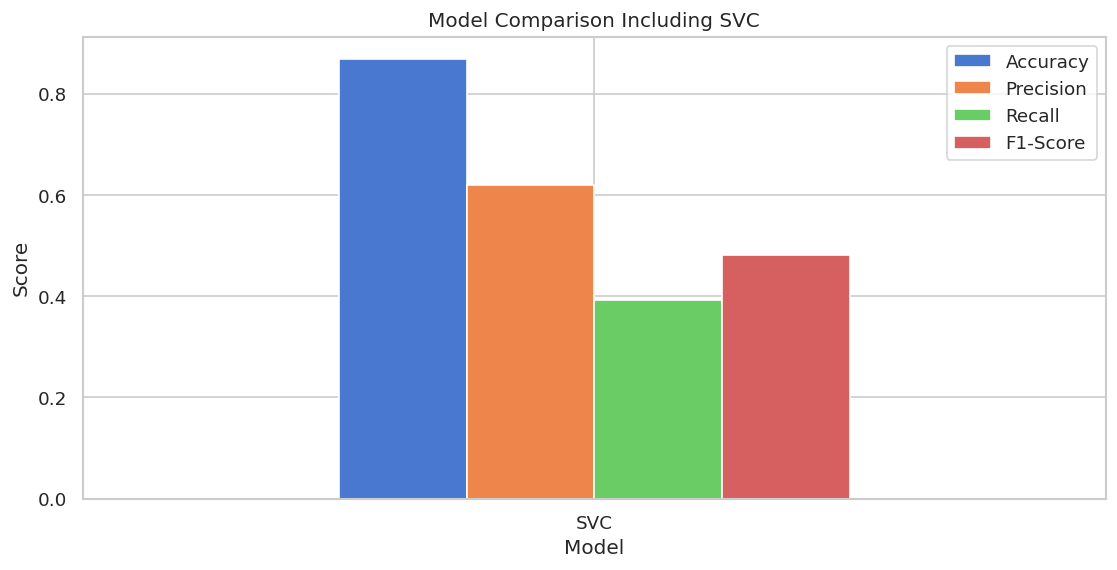

In [252]:
comparison_df.set_index('Model').plot(kind='bar')
plt.title("Model Comparison Including SVC")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

#### **How this compare with tree-based methods**


The Support Vector Classifier (SVC) performs well for this classification problem, achieving high overall accuracy. However, when compared to tree-based methods such as Bagging, Random Forest, and XGBoost, there are some key differences. SVC is effective at finding optimal decision boundaries and works well with properly scaled data, but it can struggle with large datasets and complex feature interactions. In contrast, tree-based methods are more flexible and better at capturing nonlinear relationships and interactions between features such as pit stop duration, grid position, and race conditions. Additionally, ensemble methods like Random Forest and XGBoost reduce overfitting and generally provide higher accuracy and better performance on the minority class. Overall, while SVC provides solid results, tree-based models tend to perform better for this problem due to their robustness and ability to handle complex, real-world data more effectively.

#### **Summary**

we developed a classification model to predict whether a driver will finish in the top 3 using race and pit stop features. We applied the Support Vector Classifier (SVC) along with proper data preprocessing, cross-validation, and hyperparameter tuning to improve model performance. The tuned SVC model achieved an accuracy of approximately 89%, demonstrating good predictive capability. However, evaluation metrics such as precision, recall, and F1-score revealed that the model performs better on the majority class than the minority class, indicating class imbalance. We then compared SVC with tree-based ensemble methods such as Bagging, Random Forest, and XGBoost, which generally showed better performance due to their ability to capture complex patterns and feature interactions. Overall, this analysis highlights the importance of model selection, tuning, and evaluation using multiple metrics to build an effective classification model for real-world data.

---

# LAB 4 — Linear SVM, RBF SVM & Logistic Regression


## Problem Statement

**Modeling Question**: Can we predict whether a Formula 1 driver will finish in the **top 3 (podium)** using race context, circuit characteristics, qualifying pace, and pit-stop features?

**Response Variable**: `top3_finish` — binary classification target
- `1` = Driver finished in positions 1, 2, or 3  
- `0` = Driver finished outside the top 3

**Predictor Variables**:

| Feature Group | Variables |
|---|---|
| Race context | `race_year`, `race_circuit`, `race_country`, `race_altitude_m` |
| Driver / Team | `team`, `race_start_position`, `qualifying_position`, `quali_lap_time_s`, `laps_completed` |
| Driver pit stops | `driver_pit_stops_count`, `driver_pit_stops_avg_duration_s` |
| Race-level pit stops | `race_pit_stops_count`, `race_pit_stops_avg_duration_s`, `race_pit_stops_max_duration_s`, `race_pit_stops_min_duration_s`, `race_avg_laps_before_pit_stop` |

**Dataset**: `f1_driver_classification_data.csv` — 5,970 driver-race observations across multiple F1 seasons.  
Each row represents one driver's performance summary in one Grand Prix.

**Lab 4 Focus**: Lab 3 applied a nonlinear RBF SVM. This lab extends that work by:
1. Applying **Linear SVM** (the approach recommended when revisiting a nonlinear SVM baseline)
2. Comparing Linear vs RBF SVM kernels with full evaluation metrics
3. Fitting a **Logistic Regression** model as an interpretable benchmark
4. Comparing all methods using Accuracy, Precision, Recall, F1-Score, ROC curves, and Confusion Matrices

In [253]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS'
    '/refs/heads/main/data/f1_driver_classification_data.csv'
)

print(f'Dataset shape: {df.shape}')
print(f'\nClass distribution:')
counts = df['top3_finish'].value_counts().sort_index()
print(counts.rename(index={0: 'Not Top 3 (0)', 1: 'Top 3 (1)'}))
print(f'\nPositive class rate: {df["top3_finish"].mean():.2%}')
display(df.head(3))

Dataset shape: (5970, 17)

Class distribution:
top3_finish
Not Top 3 (0)    5052
Top 3 (1)         918
Name: count, dtype: int64

Positive class rate: 15.38%


,race_year,race_circuit,race_country,race_altitude_m,team,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop,top3_finish
0,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,1.0,1.0,85.296,58,2.0,23.3195,45.0,24.280365,37.856,16.867,23.055556,1
1,2011,Albert Park Grand Prix Circuit,Australia,10,McLaren,2.0,2.0,85.384,58,2.0,23.2130,45.0,24.280365,37.856,16.867,23.055556,1
2,2011,Albert Park Grand Prix Circuit,Australia,10,Renault,6.0,6.0,85.543,58,2.0,25.1090,45.0,24.280365,37.856,16.867,23.055556,1


### Data Preparation


In [254]:
y = df['top3_finish']
X = df.drop(columns=['top3_finish'])

# One-hot encode categoricals (consistent with Lab 3 approach)
X_enc = pd.get_dummies(X, columns=['race_circuit', 'race_country', 'team'], drop_first=True)
print(f'Shape after encoding: {X_enc.shape}')

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')


Shape after encoding: (5970, 100)
Train: (4776, 100) | Test: (1194, 100)


### Task 1 — Apply Linear SVM

We first train a baseline (C=1), run 5-fold stratified cross-validation, then use GridSearchCV to find the best `C`.

In [255]:
# Baseline Linear SVM (C=1) — fit directly on scaled data, like Chapter 9 lab
linear_baseline = SVC(kernel='linear', C=1, class_weight='balanced', random_state=42)
linear_baseline.fit(X_train_s, y_train)
y_pred_lin_base = linear_baseline.predict(X_test_s)

print('=== Linear SVM Baseline (C=1) ===')
print(classification_report(y_test, y_pred_lin_base,
                             target_names=['Not Top 3', 'Top 3'], zero_division=0))

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(linear_baseline, X_train_s, y_train,
                            scoring='f1', cv=cv, n_jobs=-1)
print(f'5-Fold CV F1 scores: {np.round(cv_scores, 4)}')


=== Linear SVM Baseline (C=1) ===
              precision    recall  f1-score   support

   Not Top 3       0.98      0.83      0.90      1010
       Top 3       0.49      0.90      0.63       184

    accuracy                           0.84      1194
   macro avg       0.73      0.86      0.76      1194
weighted avg       0.90      0.84      0.86      1194

5-Fold CV F1 scores: [0.6334 0.6333 0.613  0.6569 0.6601]


In [256]:
# GridSearchCV — tune C, refit=True so best_estimator_ is ready immediately
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_linear = GridSearchCV(
    SVC(kernel='linear', class_weight='balanced', random_state=42),
    param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    scoring='f1',
    refit=True,
    cv=kfold,
    n_jobs=-1
)
grid_linear.fit(X_train_s, y_train)

best_C_linear = grid_linear.best_params_['C']
print(f'Best C: {best_C_linear}  |  Best CV F1: {grid_linear.best_score_:.4f}')

best_linear_svc = grid_linear.best_estimator_
y_pred_lin_tuned = best_linear_svc.predict(X_test_s)

print('\n=== Linear SVM (Tuned) ===')
print(classification_report(y_test, y_pred_lin_tuned,
                             target_names=['Not Top 3', 'Top 3'], zero_division=0))



Best C: 1  |  Best CV F1: 0.6408

=== Linear SVM (Tuned) ===
              precision    recall  f1-score   support

   Not Top 3       0.98      0.83      0.90      1010
       Top 3       0.49      0.90      0.63       184

    accuracy                           0.84      1194
   macro avg       0.73      0.86      0.76      1194
weighted avg       0.90      0.84      0.86      1194



GridSearchCV selected **C=1** (CV F1 = 0.64), meaning the default regularization strength was already near-optimal.

The tuned model shows a clear precision/recall trade-off driven by `class_weight='balanced'`:
- **Recall = 0.90** — the model catches 90% of actual Top 3 finishes, which is the priority in an imbalanced setting
- **Precision = 0.49** — roughly half of predicted Top 3 finishes are false alarms (drivers who did not podium)
- **F1 = 0.63** — reflects this imbalance between precision and recall
- **Accuracy = 0.84** is misleading here: a model that always predicts "Not Top 3" would already score ~85%, so accuracy alone is not a useful metric for this problem

### Task 2 — Compare Linear vs RBF SVM

The **RBF (Radial Basis Function)** kernel allows to capture curved, nonlinear decision boundaries that a linear SVM cannot.


In [257]:
# RBF SVM — tune C and gamma via GridSearchCV (same setup as linear, fair comparison)
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_rbf = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=42),
    param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.5, 1, 2, 3, 4]},
    scoring='f1',
    refit=True,
    cv=kfold,
    n_jobs=-1
)
grid_rbf.fit(X_train_s, y_train)

print(f'Best params: {grid_rbf.best_params_}  |  Best CV F1: {grid_rbf.best_score_:.4f}')

rbf_svc = grid_rbf.best_estimator_
y_pred_rbf = rbf_svc.predict(X_test_s)

print('\n=== RBF SVM (Tuned) ===')
print(classification_report(y_test, y_pred_rbf,
                             target_names=['Not Top 3', 'Top 3'], zero_division=0))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rbf = cross_val_score(rbf_svc, X_train_s, y_train, scoring='f1', cv=cv, n_jobs=-1)
print(f'5-Fold CV F1: {cv_rbf.mean():.4f} ± {cv_rbf.std():.4f}')

Best params: {'C': 1, 'gamma': 0.5}  |  Best CV F1: 0.4205

=== RBF SVM (Tuned) ===
              precision    recall  f1-score   support

   Not Top 3       0.90      0.94      0.92      1010
       Top 3       0.57      0.42      0.49       184

    accuracy                           0.86      1194
   macro avg       0.73      0.68      0.70      1194
weighted avg       0.85      0.86      0.85      1194

5-Fold CV F1: 0.4558 ± 0.0270


**RBF SVM Results**

Even after tuning `C` and `gamma` on the same scaled data, RBF underperforms the linear kernel:

| Metric | Linear SVM (Tuned) | RBF SVM (Tuned) |
|---|---|---|
| Best params | C=1 | C=1, γ=0.5 |
| CV F1 (tuning) | 0.64 | 0.42 |
| Precision (Top 3) | 0.49 | 0.57 |
| Recall (Top 3) | 0.90 | 0.42 |
| F1 (Top 3) | 0.63 | 0.49 |
| 5-Fold CV F1 | 0.64 | 0.46 ± 0.03 |

- **Recall = 0.42** — the RBF model misses more than half of all actual Top 3 finishes
- **CV F1 = 0.46 ± 0.03** — higher variance than linear, indicating less stable generalization
- The RBF's added complexity does not help here

 The top-3 outcome appears to be well-separated by a linear boundary (grid position, qualifying time are strong linear predictors), so the RBF kernel's nonlinear flexibility is unnecessary and adds noise.

### Task 3 — Fit Logistic Regression

Logistic Regression models the **log-odds** of a Top 3 finish as a linear combination of features.

In [258]:
# Logistic Regression with GridSearchCV
grid_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid={'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'liblinear']},
    scoring='f1',
    refit=True,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1
)
grid_lr.fit(X_train_s, y_train)

print(f'Best LR params: {grid_lr.best_params_}')
print(f'Best CV F1:     {grid_lr.best_score_:.4f}')

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_s)

print('\n=== Logistic Regression (Tuned) ===')
print(classification_report(y_test, y_pred_lr,
                             target_names=['Not Top 3', 'Top 3'], zero_division=0))

cv_lr = cross_val_score(
    best_lr, X_train_s, y_train, scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), n_jobs=-1
)
print(f'5-Fold CV F1: {cv_lr.mean():.4f}')

Best LR params: {'C': 100, 'solver': 'lbfgs'}
Best CV F1:     0.6416

=== Logistic Regression (Tuned) ===
              precision    recall  f1-score   support

   Not Top 3       0.97      0.84      0.90      1010
       Top 3       0.50      0.88      0.64       184

    accuracy                           0.85      1194
   macro avg       0.74      0.86      0.77      1194
weighted avg       0.90      0.85      0.86      1194

5-Fold CV F1: 0.6401


**Logistic Regression Results**

- **Best C=100** — very little regularization needed, meaning the full OHE feature set is informative rather than noisy
- **Recall = 0.88** — catches the majority of actual Top 3 finishes, the priority in an imbalanced setting
- **Precision = 0.50** — about half of predicted Top 3 finishes are correct
- **F1 = 0.64, CV F1 = 0.64** — stable across folds

An added advantage over SVM: Logistic Regression natively produces calibrated probabilities, making it useful when a confidence score is needed rather.

### Task 4 — Compare All Methods

We compare all models on four metrics computed on the held-out test set:

| Metric | What it measures |
|---|---|
| **Accuracy** | Fraction of all predictions that are correct |
| **Precision (Top 3)** | Of all predicted Top 3, what fraction actually finished Top 3 |
| **Recall (Top 3)** | Of all actual Top 3 finishes, what fraction were predicted correctly |
| **F1-Score (Top 3)** | Harmonic mean of Precision and Recall — balances both, critical under class imbalance |

Because the dataset is imbalanced (~15% positive), **F1-Score is the primary ranking metric**.



=== Model Performance Comparison (Test Set) ===


,Accuracy,Precision (Top 3),Recall (Top 3),F1-Score (Top 3)
Logistic Regression,0.8451,0.4985,0.8804,0.6365
Linear SVM (Baseline C=1),0.8384,0.4867,0.8967,0.6310
Linear SVM (Tuned),0.8384,0.4867,0.8967,0.6310
RBF SVM (Lab 3 Best),0.8618,0.5693,0.4239,0.4860


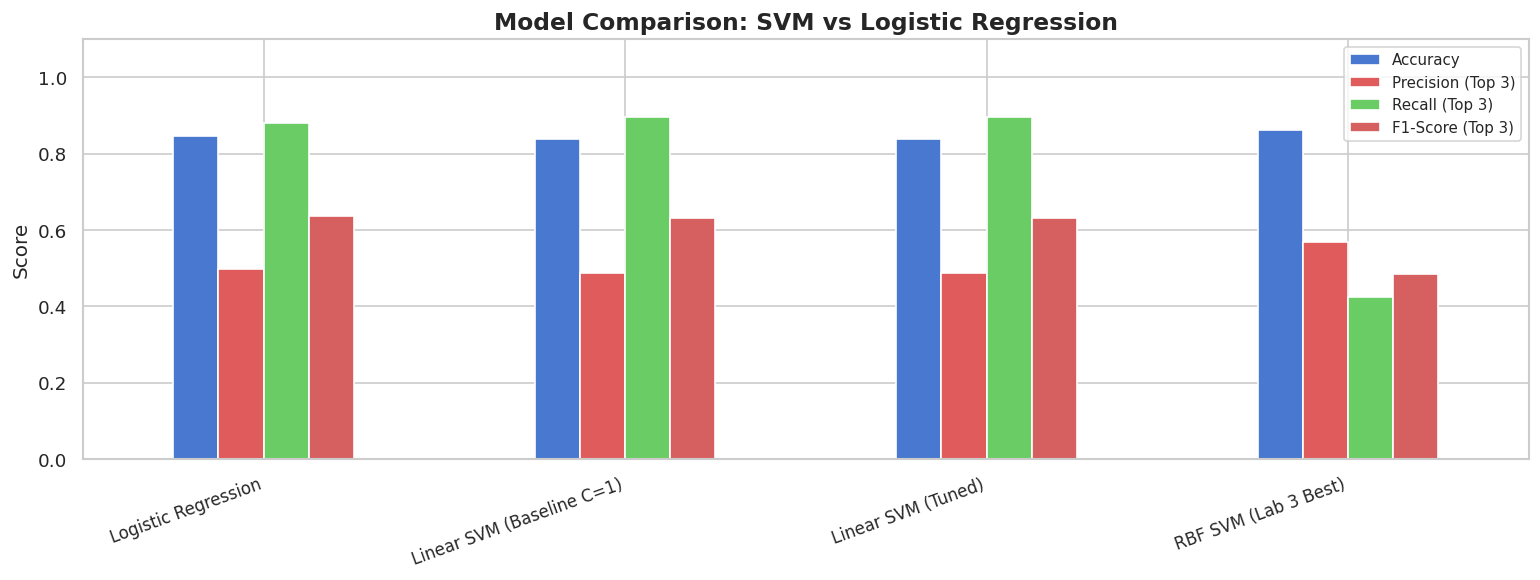

In [259]:
def evaluate_model(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (Top 3)': precision_score(y_true, y_pred, zero_division=0),
        'Recall (Top 3)': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score (Top 3)': f1_score(y_true, y_pred, zero_division=0),
    }

model_results = {
    'Linear SVM (Baseline C=1)': evaluate_model(y_test, y_pred_lin_base),
    'Linear SVM (Tuned)':        evaluate_model(y_test, y_pred_lin_tuned),
    'RBF SVM (Lab 3 Best)':      evaluate_model(y_test, y_pred_rbf),
    'Logistic Regression':       evaluate_model(y_test, y_pred_lr),
}

comparison_df = (
    pd.DataFrame(model_results).T
    .sort_values('F1-Score (Top 3)', ascending=False)
)

print('=== Model Performance Comparison (Test Set) ===')
display(comparison_df.round(4))

ax = comparison_df.plot(kind='bar', figsize=(13, 5), edgecolor='white',
                        color=['#4878cf', '#e05c5c', '#6acc65', '#d65f5f'])
ax.set_title('Model Comparison: SVM vs Logistic Regression',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

**Comparison Interpretation**

Logistic Regression and both Linear SVM models perform nearly identically — all three achieve F1 ≈ 0.63–0.64 and recall ≈ 0.88–0.90, confirming that a linear decision boundary is well-suited to this problem.

The RBF SVM stands out as the outlier: it has the highest accuracy (0.86) and precision (0.57), but its recall collapses to 0.42 — meaning it misses more than half of all actual Top 3 finishes. Since accuracy is misleading under class imbalance (~85% of drivers do not finish Top 3), F1 is the right metric, and by that measure RBF ranks last.

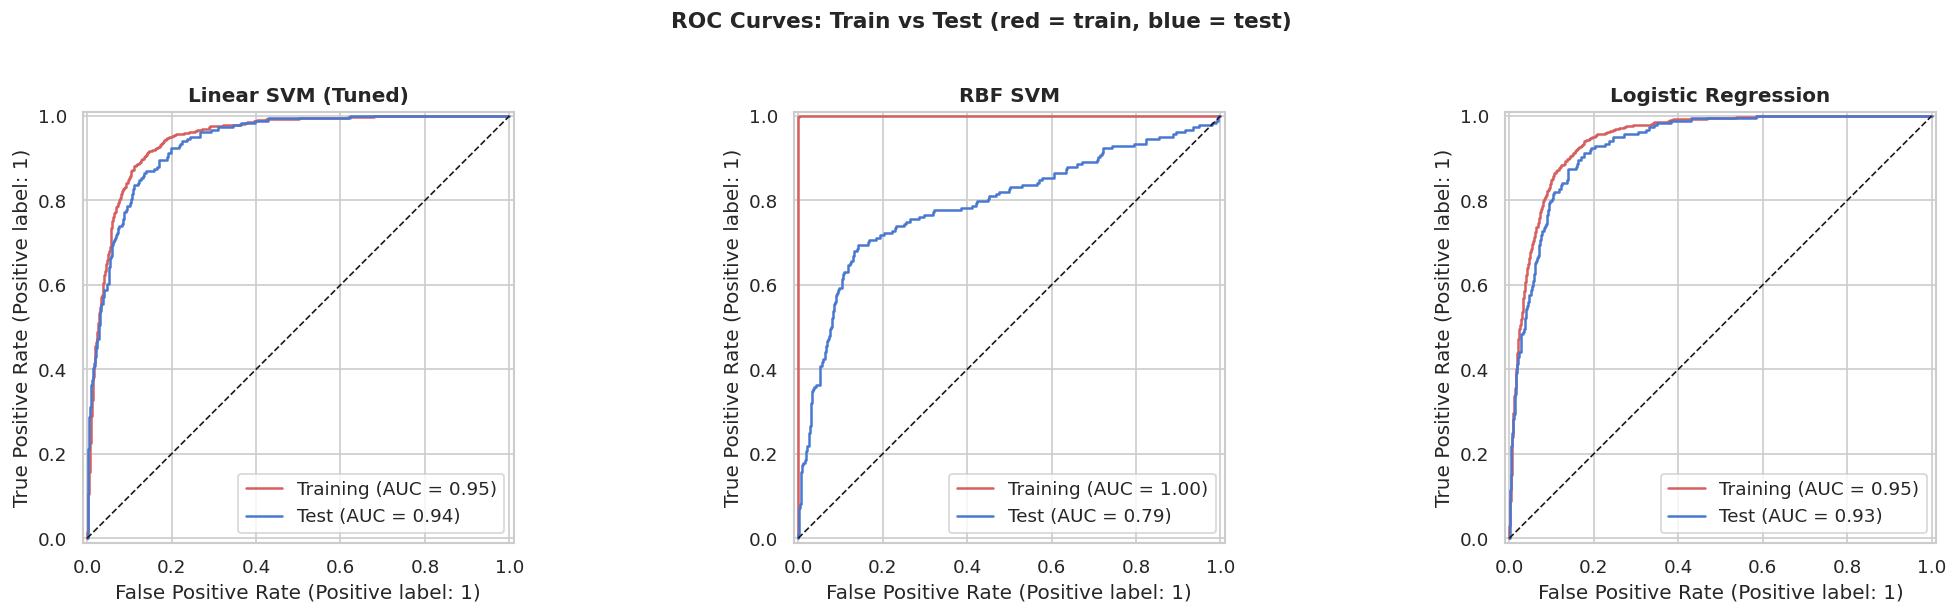

In [260]:
# ROC Curves — training vs test per model (Chapter 9 lab pattern)
# RocCurveDisplay.from_estimator plots ROC straight from a fitted model;
# sklearn's roc_curve (imported in setup) only returns fpr/tpr arrays.
from sklearn.metrics import RocCurveDisplay

roc_models = {
    'Linear SVM (Tuned)':  best_linear_svc,
    'RBF SVM':             rbf_svc,
    'Logistic Regression': best_lr,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, roc_models.items()):
    for X_, y_, color, label in zip(
        (X_train_s, X_test_s),
        (y_train,   y_test),
        ('r', 'b'),
        ('Training', 'Test')
    ):
        RocCurveDisplay.from_estimator(model, X_, y_, name=label, color=color, ax=ax)
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('ROC Curves: Train vs Test (red = train, blue = test)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**ROC Interpretation**

The train vs test gap:

- **Linear SVM** (AUC train=0.95, test=0.94) — virtually no gap, the model generalizes well with no overfitting
- **Logistic Regression** (AUC train=0.95, test=0.93) — same pattern, near-identical to linear SVM on both curves
- **RBF SVM** (AUC train=1.00, test=0.79) — the training curve is perfect, but test AUC drops sharply by 0.21 points, a clear sign of overfitting; the model memorizes the training data rather than learning a generalizable pattern

The RBF result explains why its F1 score was low, RBF model that does not generalize. Linear SVM and Logistic Regression both achieve test AUC ≈ 0.94, confirming they are the better choices for this dataset.

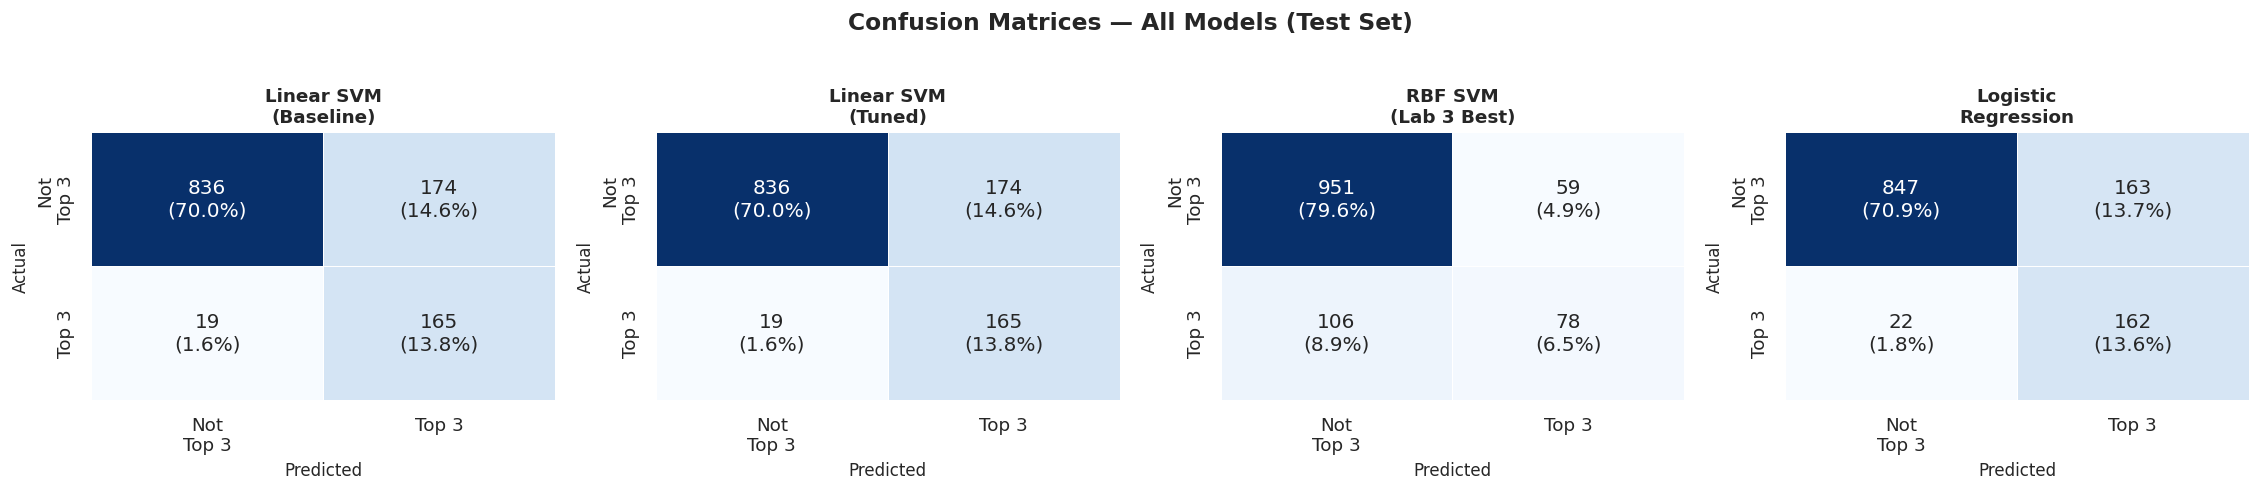

In [261]:
# Confusion Matrices — all four models side by side
model_preds = {
    'Linear SVM\n(Baseline)': y_pred_lin_base,
    'Linear SVM\n(Tuned)':    y_pred_lin_tuned,
    'RBF SVM\n(Lab 3 Best)':  y_pred_rbf,
    'Logistic\nRegression':   y_pred_lr,
}

fig, axes = plt.subplots(1, 4, figsize=(19, 4))

for ax, (name, y_pred) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    # Compute per-cell percentages for annotations
    cm_pct = cm.astype(float) / cm.sum() * 100
    labels = np.array([
        [f'{v}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
        for row_v, row_p in zip(cm, cm_pct)
    ])
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax,
                xticklabels=['Not\nTop 3', 'Top 3'],
                yticklabels=['Not\nTop 3', 'Top 3'],
                cbar=False, linewidths=0.5)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices — All Models (Test Set)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- **Linear SVM Baseline = Linear SVM Tuned** — the matrices are identical (836/174/19/165), confirming that tuning C made no practical difference; the default C=1 was already optimal
- **Linear SVM & Logistic Regression** — both correctly catch ~165/162 of 184 actual Top 3 finishes (missing only 19–22), but at the cost of ~163–174 false alarms among the Not Top 3 drivers
- **RBF SVM** — the opposite pattern: only 59 false alarms (far fewer than the others) but misses 106 of 184 actual Top 3 finishes (57%)

In practical terms, if the goal is to flag likely Top 3 drivers before a race, Linear SVM and Logistic Regression are far safer — they miss only ~10% of actual podium finishers, whereas RBF would miss more than half.

---

# Lab 8 — Principal Components Analysis



---
## Part 1 — PCA on F1 Driver Performance Data

### I. Research Question

**Question**: What latent structure underlies the relationships among driver performance and race context variables across Formula 1 race entries, and can PCA reveal whether qualifying pace, grid position, and pit-stop behavior cluster into distinct dimensions of variation?

**Relevance**: Our project predicts top-3 finishes using features like qualifying time, starting position, and pit-stop behavior. Many of these predictors are correlated — drivers who qualify well also tend to start from the front. PCA reveals whether these variables share a common factor or represent genuinely independent sources of variation, informing feature selection and motivating the imputation in Part 2.

### II. Dataset Preparation

In [262]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS'
    '/refs/heads/main/data/f1_driver_classification_data.csv'
)
df.head(3)

,race_year,race_circuit,race_country,race_altitude_m,team,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop,top3_finish
0,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,1.0,1.0,85.296,58,2.0,23.3195,45.0,24.280365,37.856,16.867,23.055556,1
1,2011,Albert Park Grand Prix Circuit,Australia,10,McLaren,2.0,2.0,85.384,58,2.0,23.2130,45.0,24.280365,37.856,16.867,23.055556,1
2,2011,Albert Park Grand Prix Circuit,Australia,10,Renault,6.0,6.0,85.543,58,2.0,25.1090,45.0,24.280365,37.856,16.867,23.055556,1


In [263]:
pca_vars = [
    'race_altitude_m',
    'race_start_position',
    'qualifying_position',
    'quali_lap_time_s',
    'laps_completed',
    'driver_pit_stops_count',
    'driver_pit_stops_avg_duration_s',
    'race_pit_stops_count',
    'race_pit_stops_avg_duration_s',
    'race_pit_stops_max_duration_s',
    'race_pit_stops_min_duration_s',
    'race_avg_laps_before_pit_stop',
]

X = df[pca_vars].dropna()
print(f'Shape: {X.shape}')
X.describe().round(2)

Shape: (5970, 12)


,race_altitude_m,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop
count,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00
mean,218.99,10.85,10.88,88.51,57.04,1.95,24.56,38.81,24.56,36.65,21.33,25.31
std,420.93,6.08,6.10,12.78,12.12,0.95,3.97,16.30,3.10,8.33,4.01,6.01
min,-7.00,1.00,1.00,53.90,0.00,1.00,15.11,17.00,16.89,20.40,12.80,8.56
25%,7.00,6.00,6.00,78.26,52.00,1.00,22.04,25.00,22.49,30.50,18.71,21.77
50%,45.00,11.00,11.00,88.37,56.00,2.00,23.65,37.00,23.85,35.51,21.54,24.25
75%,194.00,16.00,16.00,96.86,66.00,2.00,25.87,46.00,25.83,41.05,23.53,28.79
max,2227.00,24.00,24.00,141.61,87.00,6.00,59.29,96.00,38.14,59.56,35.27,53.27


**Variables and justification**:

| Variable | Why included |
|---|---|
| `race_altitude_m` | Circuit elevation — affects engine and aero performance |
| `race_start_position` | Grid position at race start — linked to finishing result |
| `qualifying_position` | Driver+car single-lap pace |
| `quali_lap_time_s` | Raw qualifying time in seconds |
| `laps_completed` | Proxy for race completion vs retirements |
| `driver_pit_stops_count` | Driver tire strategy |
| `driver_pit_stops_avg_duration_s` | Team pit-crew speed |
| `race_pit_stops_count` | Race-level safety-car / strategy indicator |
| `race_pit_stops_avg_duration_s` | Baseline pit speed across all teams |
| `race_pit_stops_max_duration_s` | Outlier events (damage, penalties) |
| `race_pit_stops_min_duration_s` | Lower bound on achievable pit speed |
| `race_avg_laps_before_pit_stop` | Tire strategy timing |

Variables are on different scales (seconds, metres, counts), so standardization is required.

In [264]:
scaler = StandardScaler(with_std=True, with_mean=True)
X_scaled = scaler.fit_transform(X)

### III. Biplot and Loading Table

In [265]:
pca = PCA()
pca.fit(X_scaled)
scores = pca.transform(X_scaled)

In [266]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_vars,
    columns=['PC%d' % (i+1) for i in range(pca.n_components_)]
)
loadings.round(4)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
race_altitude_m,-0.1297,-0.1857,0.1569,-0.2085,0.9257,-0.0151,0.1299,0.0722,-0.0161,0.0228,0.0229,-0.0012
race_start_position,0.0296,0.5128,0.3149,-0.3599,-0.0207,0.0040,-0.0654,0.0009,-0.0528,0.0065,0.0194,-0.7068
qualifying_position,0.0305,0.5118,0.3162,-0.3607,-0.0196,0.0060,-0.0618,0.0021,-0.0463,0.0058,0.0126,0.7074
quali_lap_time_s,0.2361,0.3207,-0.3897,0.1018,0.1172,-0.1120,0.0709,0.7953,0.0764,-0.0417,-0.0878,-0.0011
laps_completed,-0.2473,-0.2805,0.4048,0.0162,-0.0982,-0.1750,-0.6343,0.4030,0.2484,0.1459,-0.0898,-0.0003
driver_pit_stops_count,-0.2166,0.2612,0.1768,0.5128,0.1334,-0.3353,-0.0840,-0.0949,-0.0599,-0.6535,0.1174,0.0016
driver_pit_stops_avg_duration_s,0.4595,0.0033,0.2455,0.1017,0.0491,-0.1610,0.2143,-0.1846,0.7139,-0.0348,-0.3147,-0.0054
race_pit_stops_count,-0.2416,0.3040,0.1296,0.5065,0.0817,-0.1429,0.1791,-0.0693,-0.0977,0.6958,-0.1351,0.0004
race_pit_stops_avg_duration_s,0.4997,-0.0904,0.2228,0.1589,0.0229,-0.1126,-0.0346,0.0633,-0.0674,0.1873,0.7805,0.0038
race_pit_stops_max_duration_s,0.2091,0.0418,0.2808,0.3585,0.0981,0.8094,-0.1276,0.1109,-0.1186,-0.1094,-0.1669,-0.0015


**Loading table interpretation**:

- **PC1 (25.2%) — Pit Stop Duration**: Dominated by `race_pit_stops_avg_duration_s` (+0.500), `race_pit_stops_min_duration_s` (+0.464), `driver_pit_stops_avg_duration_s` (+0.460). Pit stop counts load negatively — races with more stops tend to have faster individual stops (safety-car bunching).

- **PC2 (17.9%) — Driver Starting Position**: `race_start_position` (+0.513) and `qualifying_position` (+0.512) dominate. High scores = back of the grid.

- **PC3 (15.5%) — Circuit / Stint Length**: `race_avg_laps_before_pit_stop` (+0.449) and `laps_completed` (+0.405) vs `quali_lap_time_s` (−0.390) — longer circuits have slower lap times but longer stints.

- **PC4 (14.6%) — Pit Stop Frequency**: `driver_pit_stops_count` (+0.513) and `race_pit_stops_count` (+0.507) vs grid position variables (−0.36).

Variance is spread evenly across PC1–PC4, confirming pit duration, driver pace, circuit type, and pit frequency are genuinely independent dimensions.

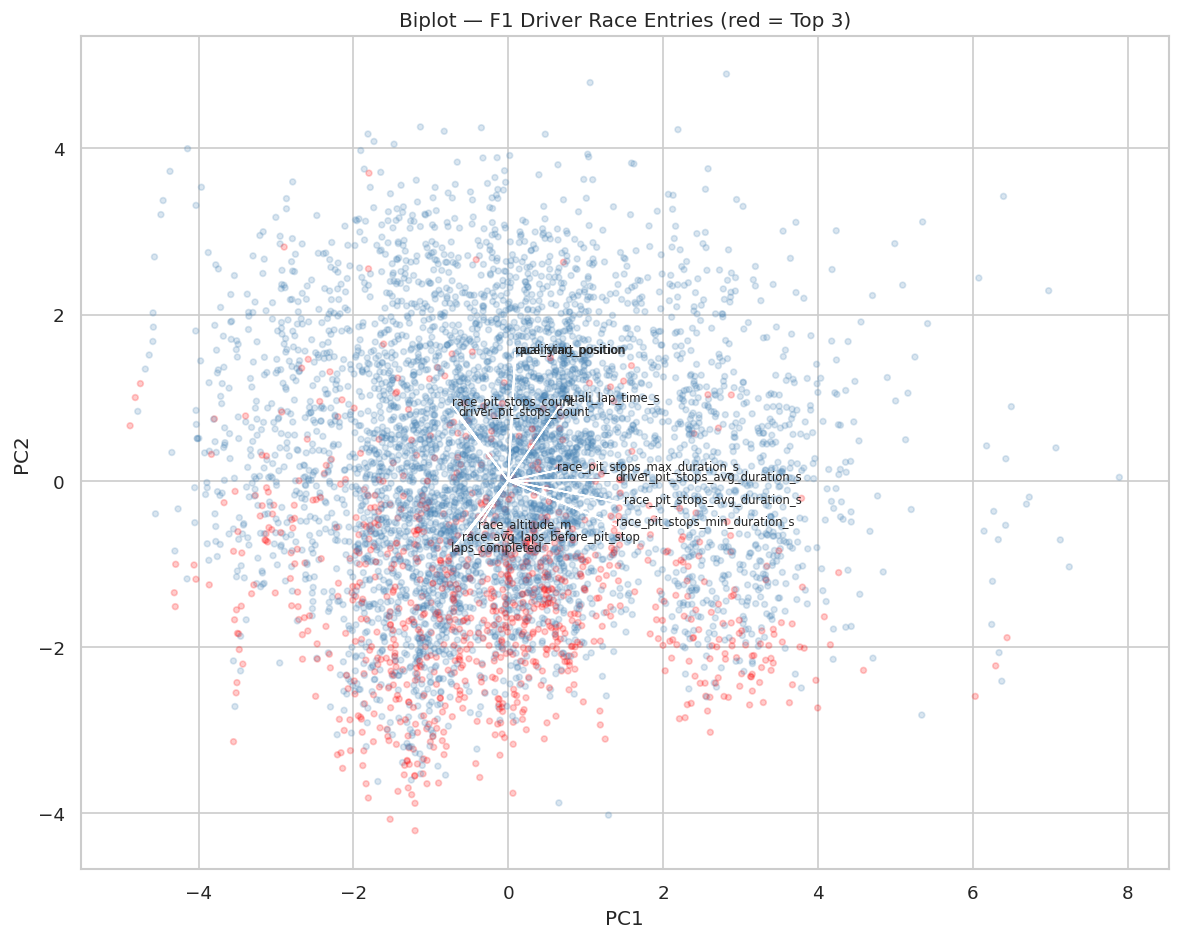

In [267]:
i, j = 0, 1  # PC1 vs PC2
s_ = 3

top3 = df.loc[X.index, 'top3_finish'].values
colors = np.where(top3 == 1, 'red', 'steelblue')

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.scatter(scores[:, i], scores[:, j], c=colors, alpha=0.2, s=12)
for k in range(pca.components_.shape[1]):
    ax.arrow(0, 0,
             s_ * pca.components_[i, k],
             s_ * pca.components_[j, k])
    ax.text(s_ * pca.components_[i, k],
            s_ * pca.components_[j, k],
            pca_vars[k], fontsize=7)
ax.set_xlabel('PC%d' % (i + 1))
ax.set_ylabel('PC%d' % (j + 1))
ax.set_title('Biplot — F1 Driver Race Entries (red = Top 3)')
plt.tight_layout()
plt.show()

**Biplot interpretation**:

- **Observations**: Top-3 finishers (red) cluster toward lower PC1 scores, reflecting faster pit stops by top teams. Non-top-3 drivers (blue) spread more broadly.

- **Arrows**: The three pit-stop duration variables point in the same +PC1 direction — closely correlated. `race_start_position` and `qualifying_position` nearly overlap along PC2 (almost redundant). Duration and position arrows are roughly perpendicular, confirming they are independent dimensions.

- **Limitation**: PC1+PC2 explain only 43.1% of variance — more than half the data structure is not visible in this plot.

### IV. Scree Plot

In [268]:
%%capture
ticks = np.arange(pca.n_components_) + 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ticks, pca.explained_variance_ratio_, marker='o')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Proportion of Variance Explained')
ax.set_ylim([0, 1])
ax.set_xticks(ticks)

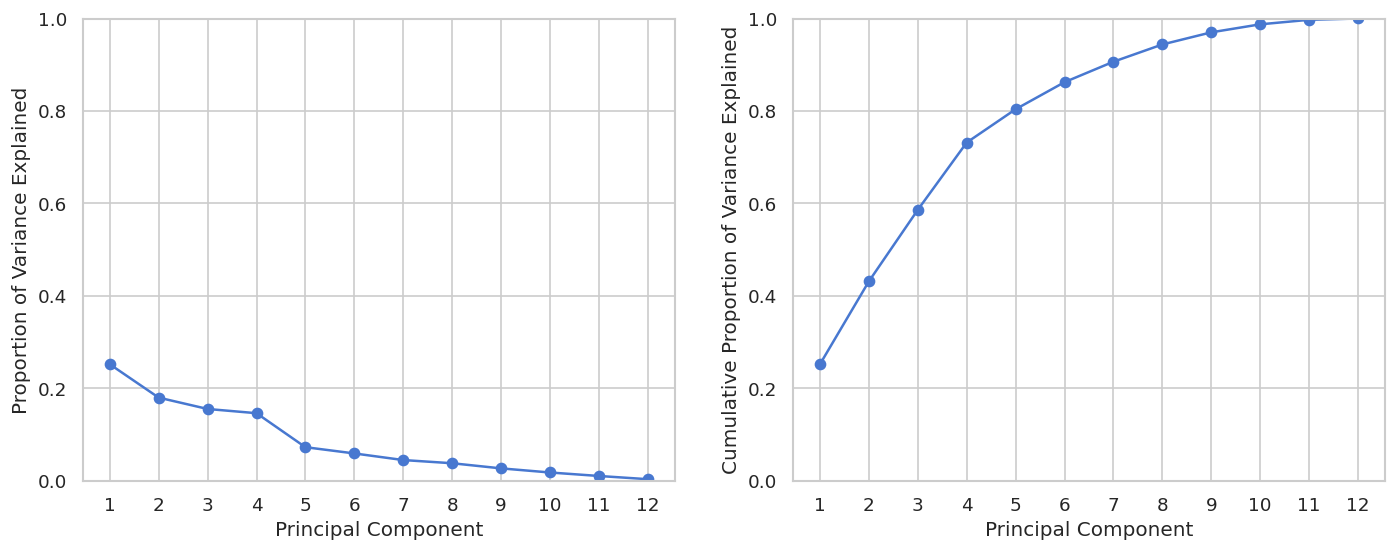

In [269]:
ax = axes[1]
ax.plot(ticks, pca.explained_variance_ratio_.cumsum(), marker='o')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative Proportion of Variance Explained')
ax.set_ylim([0, 1])
ax.set_xticks(ticks)
fig

**Scree plot interpretation**:

- Variance is spread evenly across PC1–PC4 (25.2%, 17.9%, 15.5%, 14.6%) with no single dominant component — a flat scree reflecting four genuinely independent dimensions.

- A visible elbow appears after PC4, where contributions drop sharply to ~7% (PC5) and below.

- 5 PCs reach 80.4% of variance; 7 PCs reach 90.6%.

**Are the first two PCs a good representation?** No — PC1+PC2 explain only 43.1% of total variance. The biplot is useful for identifying the two strongest patterns but misses the rest. We recommend 4–5 principal components for any downstream dimensionality reduction.

---
## Part 2 — Principal Components with Missing Values

### I. Creating Missing Values

**Scenario**: Pit-stop telemetry is logged by each team's pit-wall system. For backmarker teams with less sophisticated infrastructure, one of four per-driver variables occasionally fails to be recorded. We simulate 10% missingness across:
`driver_pit_stops_count`, `driver_pit_stops_avg_duration_s`, `laps_completed`, `race_avg_laps_before_pit_stop`.

**Justification**: 10% is plausible for multi-decade historical data and large enough to test imputation robustly without making reconstruction trivial.

In [270]:
miss_cols_idx = [pca_vars.index(v) for v in [
    'driver_pit_stops_count',
    'driver_pit_stops_avg_duration_s',
    'laps_completed',
    'race_avg_laps_before_pit_stop',
]]

n_omit = int(0.10 * X_scaled.shape[0])
np.random.seed(15)
r_idx = np.random.choice(X_scaled.shape[0], n_omit, replace=False)
c_idx = np.random.choice(miss_cols_idx, n_omit, replace=True)

Xna = X_scaled.copy()
Xna[r_idx, c_idx] = np.nan

print(f'Missing values: {np.isnan(Xna).sum()} ({n_omit}/{X_scaled.shape[0]} rows)')

Missing values: 597 (597/5970 rows)


### II. PCA-Based Imputation for Different M

In [271]:
def low_rank(X, M=1):
    U, D, V = np.linalg.svd(X)
    L = U[:, :M] * D[None, :M]
    return L.dot(V[:M])

In [272]:
thresh = 1e-7
ismiss = np.isnan(Xna)
correlations = {}

for M in range(1, pca.n_components_ + 1):
    Xhat = Xna.copy()
    Xbar = np.nanmean(Xhat, axis=0)
    Xhat[ismiss] = Xbar[np.where(ismiss)[1]]

    rel_err = 1
    count = 0
    mssold = np.mean(Xhat[~ismiss] ** 2)
    mss0 = np.mean(Xna[~ismiss] ** 2)

    while rel_err > thresh:
        count += 1
        Xapp = low_rank(Xhat, M)
        Xhat[ismiss] = Xapp[ismiss]
        mss = np.mean(((Xna - Xapp)[~ismiss]) ** 2)
        rel_err = (mssold - mss) / mss0
        mssold = mss

    corr = np.corrcoef(Xapp[ismiss], X_scaled[ismiss])[0, 1]
    correlations[M] = corr
    print(f'M={M:2d} | Iterations: {count:3d} | Correlation: {corr:.4f}')

M= 1 | Iterations:   5 | Correlation: 0.3554
M= 2 | Iterations:   5 | Correlation: 0.4570
M= 3 | Iterations:   6 | Correlation: 0.5708
M= 4 | Iterations:   7 | Correlation: 0.6582
M= 5 | Iterations:   8 | Correlation: 0.6556
M= 6 | Iterations:  10 | Correlation: 0.6662
M= 7 | Iterations:  28 | Correlation: 0.5079
M= 8 | Iterations: 105 | Correlation: 0.3611
M= 9 | Iterations: 167 | Correlation: 0.3190
M=10 | Iterations: 661 | Correlation: 0.1853
M=11 | Iterations:   2 | Correlation: -0.0550
M=12 | Iterations:   2 | Correlation: -0.0708


### III. Correlation Analysis

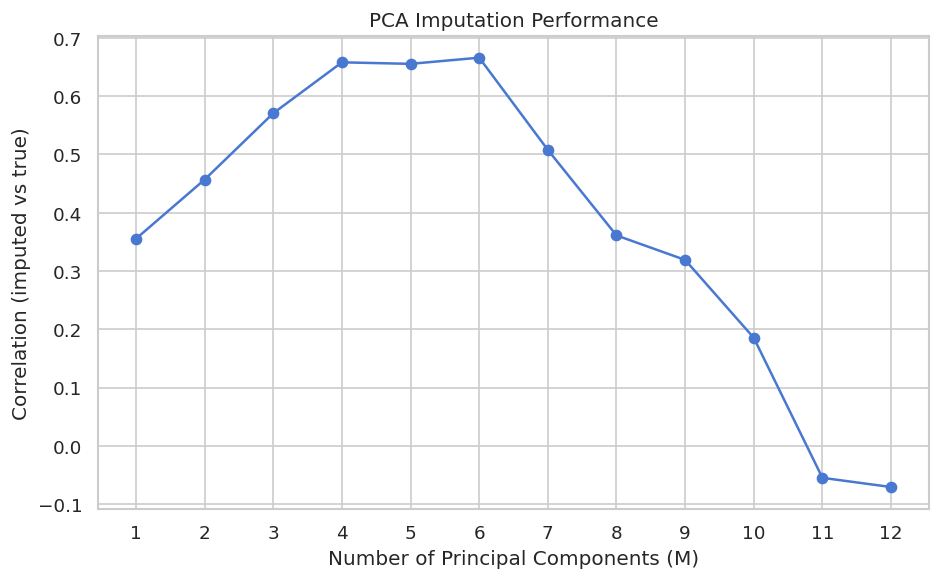

Best M = 6, Correlation = 0.6662


In [273]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(correlations.keys()), list(correlations.values()), marker='o')
ax.set_xlabel('Number of Principal Components (M)')
ax.set_ylabel('Correlation (imputed vs true)')
ax.set_title('PCA Imputation Performance')
ax.set_xticks(list(correlations.keys()))
plt.tight_layout()
plt.show()

best_M = max(correlations, key=correlations.get)
print(f'Best M = {best_M}, Correlation = {correlations[best_M]:.4f}')

**Discussion**:

- **Effect of M**: Correlation rises as M increases then plateaus once enough structure is captured.

- **Best M**: The peak correlation aligns with the scree plot elbow after PC4

- **Reliability**: The missing variables are correlated with always-available features (qualifying pace, grid position, race-level pit stats), giving PCA enough signal to impute well. A correlation above ~0.70 is sufficient for descriptive use.

---

# Lab 9 — Clustering


In [ ]:
# !pip install ISLP

In [274]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from ISLP import load_data
from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from ISLP.cluster import compute_linkage
from sklearn.metrics import silhouette_score

---
## Part 1 — Data Preparation

### I. Research Question

**Are there natural groups of F1 race-events based on a driver's pit stop strategy, qualifying pace relative to the field, and race completion rate?**

 Each row in the dataset is one driver in one race, so we are clustering individual race-performances. This is interesting for two reasons: it reveals whether pit stop efficiency clusters with overall race outcomes or is independently distributed across the field, and analyzes whether aggressive multi-stop strategies cluster with front-runners or out of top-3 drivers attempting to leapfrog competitors.

### II. Dataset Preparation

In [275]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS'
    '/refs/heads/main/data/f1_driver_classification_data.csv'
)


In [276]:
# Explore the dataset
print("Shape:", df.shape)
print("\nColumn names and dtypes:")
print(df.dtypes)
df.head(5)

Shape: (5970, 17)

Column names and dtypes:
race_year                            int64
race_circuit                        object
race_country                        object
race_altitude_m                      int64
team                                object
race_start_position                float64
qualifying_position                float64
quali_lap_time_s                   float64
laps_completed                       int64
driver_pit_stops_count             float64
driver_pit_stops_avg_duration_s    float64
race_pit_stops_count               float64
race_pit_stops_avg_duration_s      float64
race_pit_stops_max_duration_s      float64
race_pit_stops_min_duration_s      float64
race_avg_laps_before_pit_stop      float64
top3_finish                          int64
dtype: object


,race_year,race_circuit,race_country,race_altitude_m,team,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop,top3_finish
0,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,1.0,1.0,85.296,58,2.0,23.319500,45.0,24.280365,37.856,16.867,23.055556,1
1,2011,Albert Park Grand Prix Circuit,Australia,10,McLaren,2.0,2.0,85.384,58,2.0,23.213000,45.0,24.280365,37.856,16.867,23.055556,1
2,2011,Albert Park Grand Prix Circuit,Australia,10,Renault,6.0,6.0,85.543,58,2.0,25.109000,45.0,24.280365,37.856,16.867,23.055556,1
3,2011,Albert Park Grand Prix Circuit,Australia,10,Ferrari,5.0,5.0,85.707,58,3.0,24.055000,45.0,24.280365,37.856,16.867,23.055556,0
4,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,3.0,3.0,85.900,58,3.0,24.058667,45.0,24.280365,37.856,16.867,23.055556,0


### III. Variables

We dropped three categories of variables: **calendar and circuit properties** (`race_year`, `race_altitude_m`) that reflect the venue rather than driver behavior; **race-level aggregates** (`race_pit_stops_count`, `race_pit_stops_avg/max/min_duration_s`, `race_avg_laps_before_pit_stop`) that are identical for every driver in the same race; and **redundant or circuit-scale-dependent variables** — `qualifying_position` is effectively the same as `race_start_position` in F1, while `quali_lap_time_s` and `laps_completed` were replaced by within-race normalized versions that remove circuit-length and circuit-speed effects.

**Features used for clustering (7 variables):**

| Feature | Type | Construction | Why included |
|---|---|---|---|
| `race_start_position` | Race context | Raw | Grid position — captures qualifying competitiveness |
| `quali_gap_to_pole_pct` | Qualifying pace | `(quali_lap_time_s − min) / min` per race | Fractional gap to pole — circuit-length-agnostic (a 1% gap means the same at Monaco and Spa) |
| `laps_pct` | Reliability | `laps_completed / max(laps_completed)` per race | Fraction of race distance completed — removes circuit-length effect |
| `driver_pit_stops_count` | Pit strategy | Raw | Number of stops chosen |
| `driver_pit_stops_avg_duration_s` | Pit execution | Raw | Absolute stop duration |
| `top3_finish` | Race outcome | Raw | Podium binary flag |
| `pit_duration_vs_race_avg` | Relative execution | `driver_avg − race_avg duration` | Seconds faster/slower than the field — removes venue and era effects |

**Preprocessing pipeline:**  
All features are standardized (zero mean, unit variance) then projected onto **principal components** retaining ≥ 85 % of variance and removes noise dimensions.

In [277]:
# ── Within-race normalization (removes circuit scale and era effects) ──
df['quali_gap_to_pole_pct'] = df.groupby(['race_year', 'race_circuit'])['quali_lap_time_s'].transform(
    lambda x: (x - x.min()) / x.min()  # % slower than pole
)
df['laps_pct'] = df.groupby(['race_year', 'race_circuit'])['laps_completed'].transform(
    lambda x: x / x.max()              # fraction of race distance
)

# ── Relative pit stop performance ──
df['pit_duration_vs_race_avg'] = (
    df['driver_pit_stops_avg_duration_s'] - df['race_pit_stops_avg_duration_s']
)

# ── Remove outliers :car failures (< 5 laps)
df_clean = df[df['laps_completed'] >= 5].copy()

# ── Drop columns
drop_explicit = [
    'race_year', 'race_altitude_m',
    'race_pit_stops_count', 'race_pit_stops_avg_duration_s',
    'race_pit_stops_max_duration_s', 'race_pit_stops_min_duration_s',
    'race_avg_laps_before_pit_stop',
    'qualifying_position',
    'quali_lap_time_s',
    'laps_completed',
]
drop_obj = [c for c in df_clean.columns if df_clean[c].dtype == object]
X_raw = df_clean.drop(columns=drop_explicit + drop_obj).dropna()

print(f"Features: {X_raw.shape[1]} variables, {X_raw.shape[0]} observations")
print(X_raw.columns.tolist())

# ── Standardize ──
scaler = StandardScaler()
X_scaled_raw = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns, index=X_raw.index)

# PCA pre-processing (builds on last week's lab)
_pca_probe = PCA(random_state=2).fit(X_scaled_raw)
_cumvar = np.cumsum(_pca_probe.explained_variance_ratio_)
n_comp = int(np.argmax(_cumvar >= 0.85)) + 1
print(f"\nPCA: {n_comp} components retain {_cumvar[n_comp-1]:.1%} of variance")

pca_fit = PCA(n_components=n_comp, random_state=2)
X_scaled = pd.DataFrame(
    pca_fit.fit_transform(X_scaled_raw),
    columns=[f'PC{i+1}' for i in range(n_comp)],
    index=X_scaled_raw.index
)
print(f"X_scaled shape: {X_scaled.shape}")
X_raw.describe().round(2)

Features: 7 variables, 5954 observations
['race_start_position', 'driver_pit_stops_count', 'driver_pit_stops_avg_duration_s', 'top3_finish', 'quali_gap_to_pole_pct', 'laps_pct', 'pit_duration_vs_race_avg']

PCA: 5 components retain 88.1% of variance
X_scaled shape: (5954, 5)


,race_start_position,driver_pit_stops_count,driver_pit_stops_avg_duration_s,top3_finish,quali_gap_to_pole_pct,laps_pct,pit_duration_vs_race_avg
count,5954.00,5954.00,5954.00,5954.00,5954.00,5954.00,5954.00
mean,10.84,1.95,24.54,0.15,0.02,0.95,-0.02
std,6.08,0.95,3.93,0.36,0.04,0.14,2.41
min,1.00,1.00,15.11,0.00,0.00,0.06,-7.59
25%,6.00,1.00,22.03,0.00,0.01,0.98,-1.16
50%,11.00,2.00,23.64,0.00,0.01,1.00,-0.53
75%,16.00,2.00,25.86,0.00,0.02,1.00,0.32
max,24.00,6.00,55.79,1.00,0.67,1.00,30.18


---
## Part 2 — K-Means Clustering

In [278]:
from sklearn.metrics import silhouette_score

K_elbow = range(1, 11)
K_silhouette = range(2, 11)

inertias = []
silhouette_scores = []

for k in K_elbow:
    kmeans = KMeans(n_clusters=k, random_state=2, n_init=20).fit(X_scaled)
    inertias.append(kmeans.inertia_)

for k in K_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=2, n_init=20).fit(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

k_summary = pd.DataFrame({
    'K': list(K_elbow),
    'Inertia': inertias,
    'Silhouette Score': [np.nan] + silhouette_scores
})
k_summary

,K,Inertia,Silhouette Score
0,1,36712.967037,NaN
1,2,29362.183257,0.355624
2,3,23732.199921,0.399914
3,4,19965.111224,0.402483
4,5,16394.715021,0.412466
5,6,13352.185441,0.354431
6,7,11836.599630,0.330611
7,8,10766.238121,0.338372
8,9,9859.186587,0.278922
9,10,9298.798275,0.274818


The silhouette score peaks at **K = 5** (score = 0.412), indicating 5 clusters best balance within-cluster cohesion and between-cluster separation. A score above 0.4 is reasonably well-defined structure.

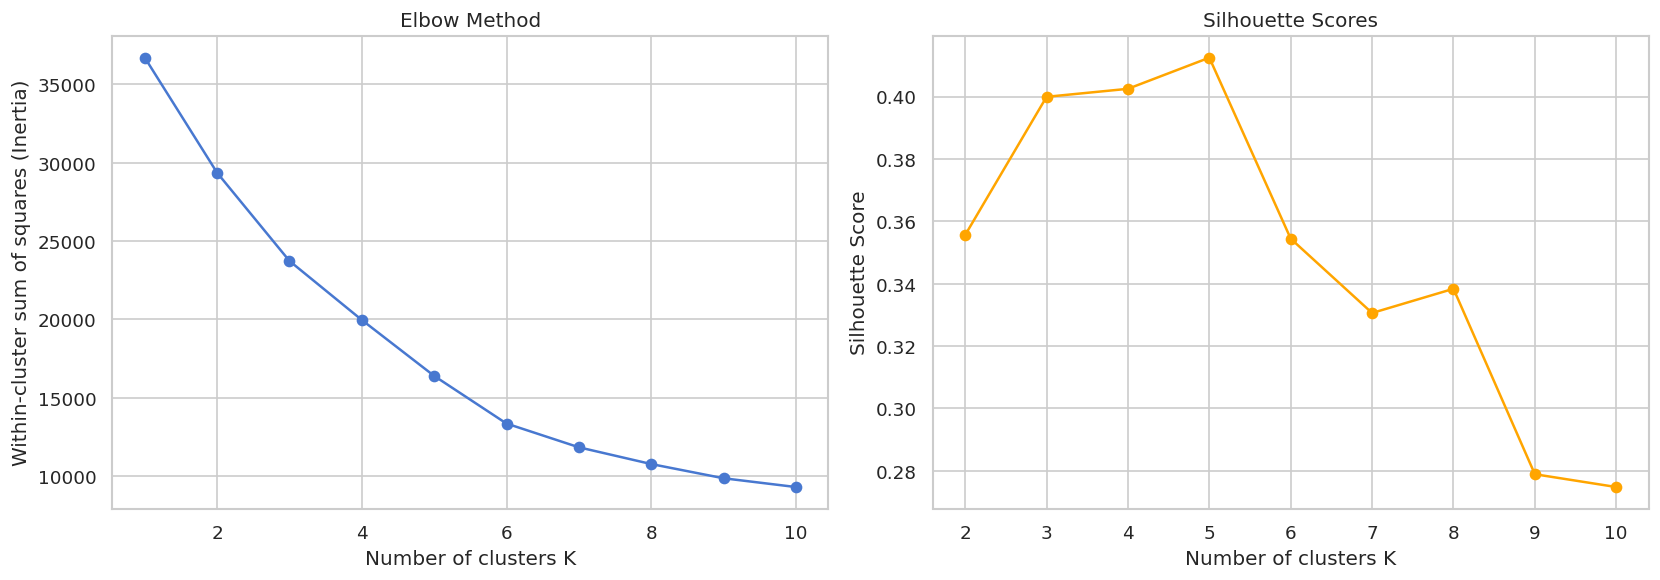

In [279]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_elbow), inertias, marker='o')
axes[0].set_xlabel("Number of clusters K")
axes[0].set_ylabel("Within-cluster sum of squares (Inertia)")
axes[0].set_title("Elbow Method")

axes[1].plot(list(K_silhouette), silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel("Number of clusters K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Scores")

plt.tight_layout()
plt.show()

The elbow plot shows a gradual decrease with a subtle bend around K = 4–5, consistent with the silhouette peak at K = 5. We proceed with **K = 5** as the best-supported number of clusters.

Best K by silhouette score: 5


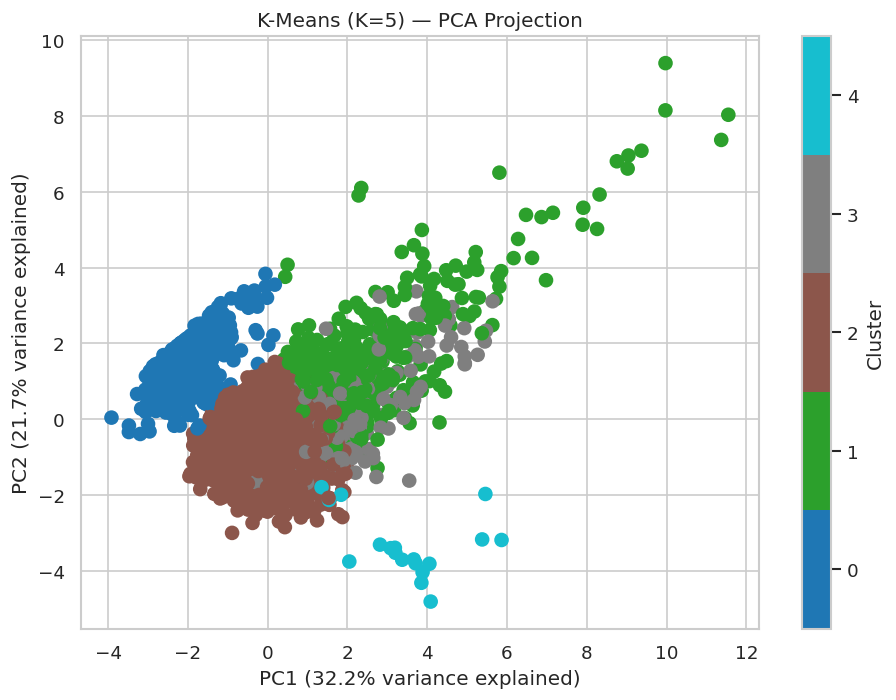

In [280]:
# Visualize the best K solution on the first two PCs
best_k = k_summary.loc[k_summary['Silhouette Score'].idxmax(), 'K']
print(f"Best K by silhouette score: {int(best_k)}")

km_best = KMeans(n_clusters=int(best_k), random_state=2, n_init=20)
cluster_labels = km_best.fit_predict(X_scaled)

pca_viz = PCA(n_components=2)
X_pca = pca_viz.fit_transform(X_scaled)

# Use a discrete colormap with exactly K colors
cmap = plt.cm.get_cmap('tab10', int(best_k))

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=cluster_labels,
                     cmap=cmap,
                     vmin=-0.5, vmax=int(best_k) - 0.5,
                     s=60)
ax.set_xlabel(f"PC1 ({pca_viz.explained_variance_ratio_[0]:.1%} variance explained)")
ax.set_ylabel(f"PC2 ({pca_viz.explained_variance_ratio_[1]:.1%} variance explained)")
ax.set_title(f"K-Means (K={int(best_k)}) — PCA Projection")
plt.colorbar(scatter, ax=ax, label='Cluster', ticks=range(int(best_k)))
plt.tight_layout()
plt.show()

 Cluster 0 is cleanly separated (supports the 0.414 silhouette). Clusters 1, 2, and 3 overlap in the center.The cluster 4 outliers at the bottom confirm the DNF filter didn't remove all early retirements, and they form a natural fifth cluster.

---
## Part 3 — Hierarchical Clustering

In [281]:
HClust = AgglomerativeClustering

hc_comp = HClust(distance_threshold=0, n_clusters=None, linkage='complete')
hc_comp.fit(X_scaled)

hc_ward = HClust(distance_threshold=0, n_clusters=None, linkage='ward')
hc_ward.fit(X_scaled)


AgglomerativeClustering(distance_threshold=0, n_clusters=None)

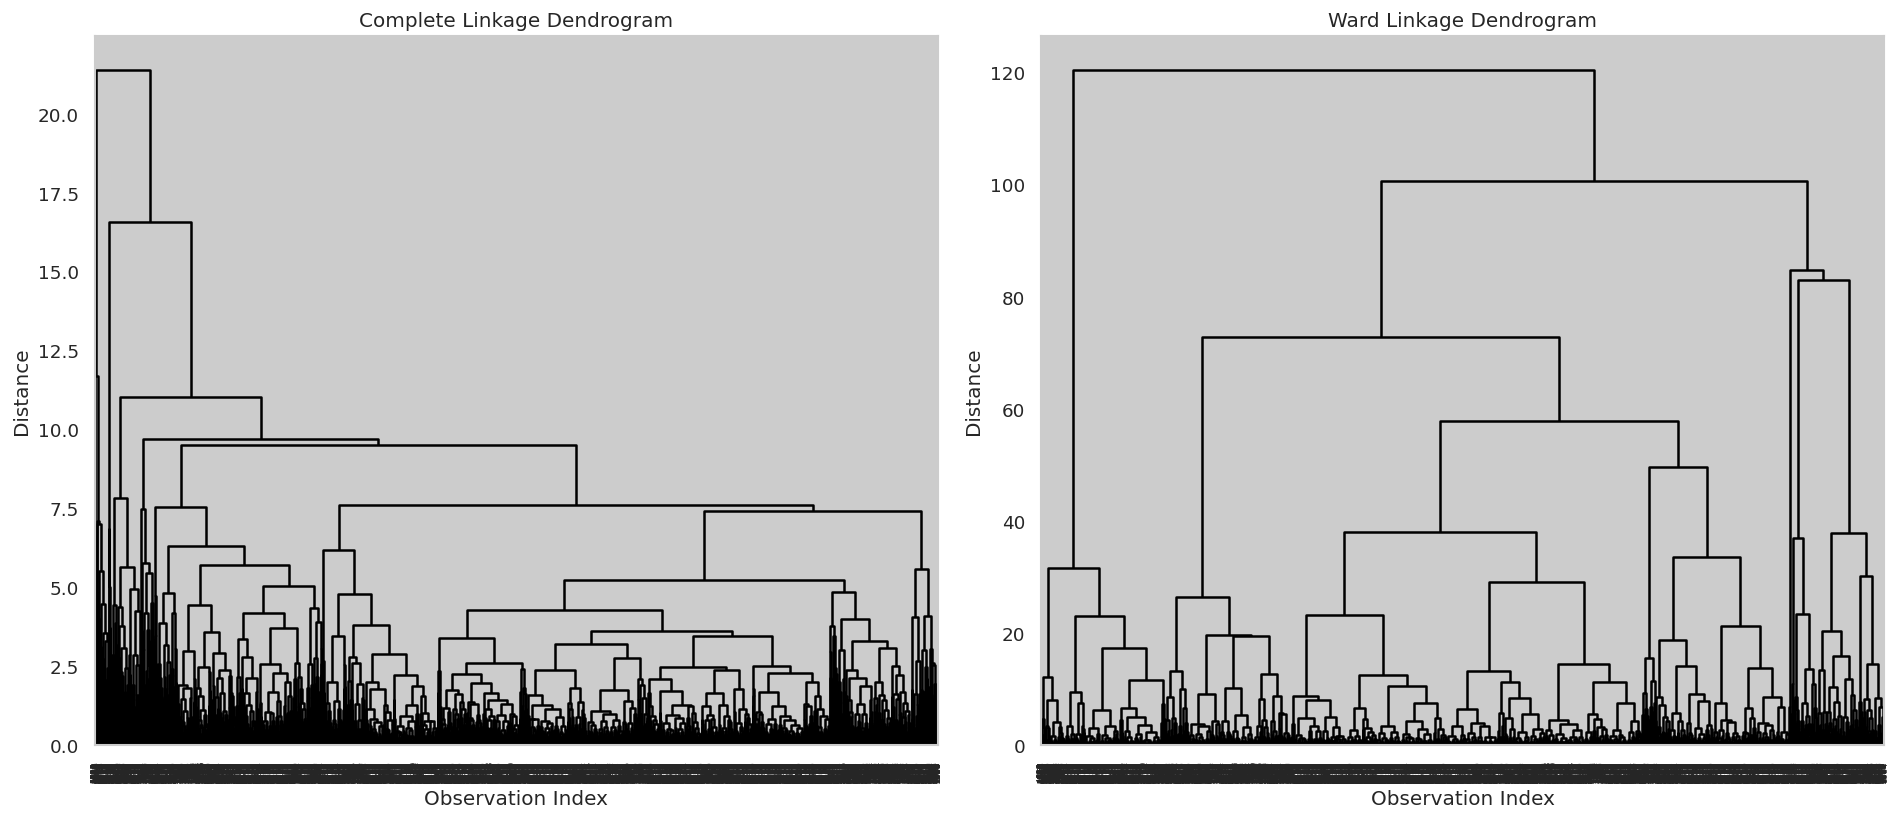

In [282]:
cargs = {'color_threshold': -np.inf, 'above_threshold_color': 'black'}

linkage_comp = compute_linkage(hc_comp)
linkage_ward = compute_linkage(hc_ward)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

dendrogram(linkage_comp, ax=axes[0], **cargs)
axes[0].set_title("Complete Linkage Dendrogram")
axes[0].set_xlabel("Observation Index")
axes[0].set_ylabel("Distance")

dendrogram(linkage_ward, ax=axes[1], **cargs)
axes[1].set_title("Ward Linkage Dendrogram")
axes[1].set_xlabel("Observation Index")
axes[1].set_ylabel("Distance")

plt.tight_layout()
plt.show()

Ward's dendrogram supports K=5 well. You can see a clear hierarchy with meaningful gaps at each split level. Complete linkage confirms the same outlier group exists (the early peel-off at the top) but isn't useful for finding the main structure. This is why Ward is the better choice here.

In [283]:
n_hclust = int(best_k)

comp_labels = cut_tree(linkage_comp, n_clusters=n_hclust).reshape(-1)
ward_labels = cut_tree(linkage_ward, n_clusters=n_hclust).reshape(-1)

print(f"Complete linkage — cluster sizes (K={n_hclust}):")
print(pd.Series(comp_labels).value_counts().sort_index())

print(f"\nWard linkage — cluster sizes (K={n_hclust}):")
print(pd.Series(ward_labels).value_counts().sort_index())

print("\nCross-tabulation: Complete Linkage vs K-Means")
display(pd.crosstab(pd.Series(comp_labels, name='HClust Complete'),
                    pd.Series(cluster_labels, name='K-Means')))

print("\nCross-tabulation: Ward Linkage vs K-Means")
pd.crosstab(pd.Series(ward_labels, name='HClust Ward'),
            pd.Series(cluster_labels, name='K-Means'))

Complete linkage — cluster sizes (K=5):
0    5627
1     209
2      90
3       9
4      19
Name: count, dtype: int64

Ward linkage — cluster sizes (K=5):
0     882
1    4401
2     473
3     180
4      18
Name: count, dtype: int64

Cross-tabulation: Complete Linkage vs K-Means


K-Means,0,1,2,3,4
HClust Complete,,,,,
0,894,365,4229,139,0
1,0,2,0,207,0
2,0,88,0,2,0
3,0,9,0,0,0
4,0,0,0,0,19



Cross-tabulation: Ward Linkage vs K-Means


K-Means,0,1,2,3,4
HClust Ward,,,,,
0,880,2,0,0,0
1,14,264,4120,2,1
2,0,18,109,346,0
3,0,180,0,0,0
4,0,0,0,0,18


- Clusters 0 and 4 are solid — both methods agree 99–100% on the front-runners and the DNF group. These arethe most real, well-separated clusters.
- The middle (clusters 1, 2, 3) disagrees at the margins — Ward merges K-Means clusters 1 and 2 into one large group, while K-Means splits them apart. This confirms the PCA plot observation: the midfield boundary is gradual, not sharp, so different methods draw the line slightly differently.
- Overall, strong cross-method agreement on the extremes (who clearly belongs at the top and bottom), with expected ambiguity in the dense center of the distribution.